# Pearson Feature-Selection Grid for SPY Combined Strategy Candidates



This notebook explores the Pearson-correlation version of the ML predictor before building a combined strategy. It mirrors the broad workflow of `test_PCA_scaler_comparison.ipynb`: configure a compact grid, run the grid in parallel, collect artifacts, build leaderboards, and inspect feature-selection diagnostics.


## First search: testing many parameter sets for year `2025` to determine top 10 and then run combined strategy.


The first candidate search is the **combined strategy for top performers in 2025**. A second candidate search is duplicated below for the longer 2023-2025 window, so we can later test top combined strategy candidates on 2026-YTD data.

### Experiment Design


The predictor is run through `run_single_case_features_Sharpe.py`, which uses the Pearson feature selector in `ML_predictor_features_Sharpe.py`. The first grid keeps the same trading assumptions used in the PCA scaler comparison: `training_years=10`, `start_date="2025-01-01"`, `end_date="2026-01-01"`, and `sharpe_filter_enabled=False`.

The `n_features` grid spans 1 to 20 in steps of 1. The `signal_threshold` grid spans 0 to 0.01 with denser low-threshold steps, because costs argue against always trading tiny predicted edges, while predictor accuracy argues against setting the threshold so high that the model almost never trades.

All grid searches use 15 parallel workers via joblib's `loky` backend.

In [1]:
from pathlib import Path
import itertools
import json
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

cwd = Path.cwd().resolve()
repo_root = cwd
while repo_root.name != "Bluegrey" and repo_root.parent != repo_root:
    repo_root = repo_root.parent

ml_dir = repo_root / "research" / "Mateo" / "ML_predictor"
src_dir = repo_root / "src"

for path in [repo_root, src_dir, ml_dir]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import run_single_case_features_Sharpe as pearson_runner_module
from src.vector_backtester_Mateo import PortfolioVectorEngine

print(f"Repo root: {repo_root}")
print(f"ML directory: {ml_dir}")


Repo root: /Users/mateo/Bluegrey
ML directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor


In [2]:
SYMBOL = "SPY"
ASSET_CLASS = "STK"
INITIAL_CAPITAL = 1_000_000
EXECUTION_DELAY = 1

N_FEATURES_GRID = list(range(1, 21))
SIGNAL_THRESHOLD_GRID = [0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.0075, 0.01]

COMMON_PARAMS_2025 = {
    "symbol": SYMBOL,
    "start_date": "2025-01-01",
    "end_date": "2026-01-01",
    "training_years": 10,
    "sharpe_filter_enabled": False,
    "feature_diagnostics_enabled": True,
    # None records all ranked Pearson feature scores available after the variance filter.
    # Set to an integer such as 30 if the diagnostics become too large.
    "feature_diagnostics_top_n": None,
    "position_size": 1.0,
    "max_iter": 5000,
    "verbose": False,
}

COMMON_PARAMS_2023_2025 = {
    **COMMON_PARAMS_2025,
    "start_date": "2023-01-01",
    "end_date": "2026-01-01",
}

# Keep this alias for cells that operate on the first candidate search by default.
COMMON_PARAMS = COMMON_PARAMS_2025

RUN_GRID = True
N_JOBS = 15
PARALLEL_VERBOSE = 10
SHOW_PROGRESS = False
SAVE_ARTIFACTS = True

OUTPUT_ROOT = ml_dir / "test_Pearson_combined_strategy_outputs"
OUTPUT_DIR_2025 = OUTPUT_ROOT / "combined_strategy_top_performers_2025"
OUTPUT_DIR_2023_2025 = OUTPUT_ROOT / "test_top_combined_strategy_2023_2025_for_2026_ytd"
for output_dir in [OUTPUT_DIR_2025, OUTPUT_DIR_2023_2025]:
    output_dir.mkdir(parents=True, exist_ok=True)

print(f"2025 output directory: {OUTPUT_DIR_2025}")
print(f"2023-2025 output directory: {OUTPUT_DIR_2023_2025}")

2025 output directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor/test_Pearson_combined_strategy_outputs/combined_strategy_top_performers_2025
2023-2025 output directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor/test_Pearson_combined_strategy_outputs/test_top_combined_strategy_2023_2025_for_2026_ytd


### Metric Helpers


These helpers compute the same family of performance and behavior metrics used in the PCA comparison notebook: returns, drawdown, Sharpe, adjusted Sortino, activity/exposure, turnover, fees, and prediction distribution.

`adjusted_net_sortino` is divided by `sqrt(2)` so it is more directly comparable with Sharpe, matching the adjustment used in the backtester tearsheet.

Return win/loss/zero rates are calculated from gross returns, not net returns. This avoids counting an otherwise-flat trading day as a losing day just because transaction costs were applied.

In [3]:
def safe_value(value):
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value.is_integer():
            return str(int(value))
        return f"{value:g}".replace(".", "p")
    return str(value)


def make_run_id(symbol: str, n_features: int, signal_threshold) -> str:
    return f"{symbol}_features-{n_features}_sig-{safe_value(signal_threshold)}"


def annualized_sharpe(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    vol = returns.std()
    if vol == 0 or np.isnan(vol):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / vol


def annualized_sortino(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    downside = returns[returns < 0]
    downside_vol = downside.std()
    if downside_vol == 0 or np.isnan(downside_vol):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / downside_vol


def adjusted_annualized_sortino(returns: pd.Series, periods_per_year: int = 252) -> float:
    sortino_value = annualized_sortino(returns, periods_per_year=periods_per_year)
    if pd.isna(sortino_value):
        return np.nan
    return sortino_value / np.sqrt(2)


def max_drawdown(equity: pd.Series) -> float:
    return (equity / equity.cummax() - 1.0).min()


def summarize_performance(
    run_id: str,
    grid_index: int,
    params: dict,
    stats: pd.DataFrame,
    weights: pd.DataFrame,
    strategy,
) -> dict:
    gross_return_pct = (stats["gross_equity"].iloc[-1] / INITIAL_CAPITAL - 1.0) * 100
    net_return_pct = (stats["net_equity"].iloc[-1] / INITIAL_CAPITAL - 1.0) * 100
    benchmark_return_pct = (stats["cum_benchmark"].iloc[-1] - 1.0) * 100

    gross_bar_returns = stats["gross_returns"].iloc[1:]
    exposure = weights.abs().sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(0)

    prediction_counts = pd.Series(dtype=float)
    if strategy.weight_diagnostics_ is not None and "prediction" in strategy.weight_diagnostics_.columns:
        prediction_counts = strategy.weight_diagnostics_["prediction"].value_counts(normalize=True).sort_index() * 100

    return {
        "grid_index": grid_index,
        "run_id": run_id,
        "symbol": params["symbol"],
        "n_features": params["n_features"],
        "signal_threshold": params["signal_threshold"],
        "training_years": params["training_years"],
        "start_date": params["start_date"],
        "end_date": params["end_date"],
        "gross_return_pct": gross_return_pct,
        "net_return_pct": net_return_pct,
        "benchmark_return_pct": benchmark_return_pct,
        "excess_vs_benchmark_pct": net_return_pct - benchmark_return_pct,
        "max_drawdown_pct": max_drawdown(stats["net_equity"]) * 100,
        "net_sharpe": annualized_sharpe(stats["net_returns"]),
        "adjusted_net_sortino": adjusted_annualized_sortino(stats["net_returns"]),
        "gross_win_rate_pct": (gross_bar_returns > 0).mean() * 100,
        "gross_loss_rate_pct": (gross_bar_returns < 0).mean() * 100,
        "gross_zero_return_rate_pct": (gross_bar_returns == 0).mean() * 100,
        "active_days_pct": (exposure > 0).mean() * 100,
        "long_days_pct": (weights.sum(axis=1) > 0).mean() * 100,
        "short_days_pct": (weights.sum(axis=1) < 0).mean() * 100,
        "flat_days_pct": (weights.sum(axis=1) == 0).mean() * 100,
        "average_abs_exposure": exposure.mean(),
        "average_daily_turnover": turnover.mean(),
        "total_fees_paid": stats["cumulative_costs"].iloc[-1],
        "prediction_minus1_pct": prediction_counts.get(-1.0, 0.0),
        "prediction_0_pct": prediction_counts.get(0.0, 0.0),
        "prediction_plus1_pct": prediction_counts.get(1.0, 0.0),
    }

### Pearson Feature Diagnostics



The Pearson predictor records the ranked absolute Pearson-correlation score for each feature on each prediction date. The summary below helps identify which features are repeatedly selected, which are merely highly ranked, and whether a candidate run depends on a narrow or broad set of indicators.

In [4]:
def feature_summary_from_diagnostics(diagnostics: pd.DataFrame) -> pd.DataFrame:
    if diagnostics is None or diagnostics.empty:
        return pd.DataFrame()

    grouped = diagnostics.groupby("feature")
    summary = grouped.agg(
        appearances=("feature", "size"),
        selected_appearances=("selected", "sum"),
        mean_abs_corr=("pearson_abs_corr", "mean"),
        median_abs_corr=("pearson_abs_corr", "median"),
        mean_rank=("rank", "mean"),
        best_rank=("rank", "min"),
    )
    summary["selection_rate_pct"] = summary["selected_appearances"] / summary["appearances"] * 100
    return summary.sort_values(
        ["selected_appearances", "mean_abs_corr"],
        ascending=[False, False],
    )


def selected_feature_counts(diagnostics: pd.DataFrame, top_n: int = 30) -> pd.Series:
    if diagnostics is None or diagnostics.empty:
        return pd.Series(dtype=float)
    selected = diagnostics[diagnostics["selected"]]
    return selected["feature"].value_counts().head(top_n)


def plot_selected_feature_frequency(feature_summary: pd.DataFrame, top_n: int = 30, title: str = "Selected Feature Frequency"):
    if feature_summary.empty:
        print("No feature summary available.")
        return None

    top = feature_summary.sort_values("selected_appearances", ascending=False).head(top_n)
    ax = top["selected_appearances"].sort_values().plot(kind="barh", figsize=(10, max(4, 0.3 * len(top))))
    ax.set_title(title)
    ax.set_xlabel("Selected appearances")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    return ax

### Runner Wrapper



`run_single_case_features_Sharpe.py` currently always creates a tearsheet and does not return the backtest artifacts. To keep this notebook self-contained without editing that script, the helper below temporarily wraps the runner's `PortfolioVectorEngine` reference, captures the generated stats/weights/prices, and suppresses tearsheet generation during grid search.

In [5]:
def run_single_case_features_capture(
    *,
    symbol: str,
    asset_class: str,
    start_date: str,
    end_date: str,
    signal_threshold: float,
    n_features: int,
    training_years: int,
    sharpe_filter_enabled: bool,
    feature_diagnostics_enabled: bool,
    feature_diagnostics_top_n,
    position_size: float,
    initial_capital: float,
    max_iter: int,
    execution_delay: int,
    verbose: bool,
    show_progress: bool,
    show_tearsheet: bool = False,
) -> dict:
    captured = {}
    original_engine_class = pearson_runner_module.PortfolioVectorEngine

    class CapturingPortfolioVectorEngine(original_engine_class):
        def run(self):
            stats = super().run()
            captured["prices"] = self.prices.copy()
            captured["weights"] = self.signals.copy()
            captured["stats"] = stats.copy()
            return stats

        def tearsheet(self, title="Multi-Asset Alpha Discovery Tearsheet"):
            if show_tearsheet:
                return super().tearsheet(title)
            return None

    pearson_runner_module.PortfolioVectorEngine = CapturingPortfolioVectorEngine
    try:
        strategy = pearson_runner_module.run_single_case_features_Sharpe(
            symbol=symbol,
            asset_class=asset_class,
            start_date=start_date,
            end_date=end_date,
            signal_threshold=signal_threshold,
            n_features=n_features,
            training_years=training_years,
            sharpe_filter_enabled=sharpe_filter_enabled,
            feature_diagnostics_enabled=feature_diagnostics_enabled,
            feature_diagnostics_top_n=feature_diagnostics_top_n,
            position_size=position_size,
            initial_capital=initial_capital,
            max_iter=max_iter,
            execution_delay=execution_delay,
            verbose=verbose,
            show_progress=show_progress,
            return_strategy=True,
        )
    finally:
        pearson_runner_module.PortfolioVectorEngine = original_engine_class

    if "stats" not in captured:
        raise ValueError("No backtest stats were captured. The runner may have produced empty weights.")

    params = {
        "symbol": symbol,
        "start_date": start_date,
        "end_date": end_date,
        "signal_threshold": signal_threshold,
        "n_features": n_features,
        "training_years": training_years,
        "sharpe_filter_enabled": sharpe_filter_enabled,
        "feature_diagnostics_enabled": feature_diagnostics_enabled,
        "feature_diagnostics_top_n": feature_diagnostics_top_n,
        "position_size": position_size,
        "max_iter": max_iter,
        "verbose": verbose,
    }

    return {
        "params": params,
        "strategy": strategy,
        "prices": captured["prices"],
        "weights": captured["weights"],
        "stats": captured["stats"],
    }

### Case Runner



This function runs one Pearson grid case, computes performance metrics, extracts feature diagnostics, and optionally saves artifacts to disk. The grid worker uses this function through a safe wrapper so failures are collected instead of stopping the whole grid.

In [6]:
def save_case_artifacts(run_id: str, artifacts: dict, output_dir: Path) -> None:
    run_dir = output_dir / run_id
    run_dir.mkdir(parents=True, exist_ok=True)

    artifacts["stats"].to_pickle(run_dir / "portfolio_stats.pkl")
    artifacts["weights"].to_pickle(run_dir / "weights.pkl")
    artifacts["prices"].to_pickle(run_dir / "prices.pkl")
    artifacts["feature_diagnostics"].to_pickle(run_dir / "feature_diagnostics.pkl")
    artifacts["feature_summary"].to_pickle(run_dir / "feature_summary.pkl")
    artifacts["weight_diagnostics"].to_pickle(run_dir / "weight_diagnostics.pkl")

    with open(run_dir / "metrics.json", "w") as f:
        json.dump(artifacts["metrics"], f, indent=2, default=str)


def run_one_case(grid_index: int, n_features: int, signal_threshold: float, common_params: dict, output_dir: Path) -> dict:
    symbol = common_params["symbol"]
    run_id = make_run_id(symbol, n_features, signal_threshold)
    print(f"Running grid_index={grid_index}: {run_id}")
    start = time.time()

    runner_artifacts = run_single_case_features_capture(
        symbol=symbol,
        asset_class=ASSET_CLASS,
        start_date=common_params["start_date"],
        end_date=common_params["end_date"],
        signal_threshold=signal_threshold,
        n_features=n_features,
        training_years=common_params["training_years"],
        sharpe_filter_enabled=common_params["sharpe_filter_enabled"],
        feature_diagnostics_enabled=common_params["feature_diagnostics_enabled"],
        feature_diagnostics_top_n=common_params["feature_diagnostics_top_n"],
        position_size=common_params["position_size"],
        initial_capital=INITIAL_CAPITAL,
        max_iter=common_params["max_iter"],
        execution_delay=EXECUTION_DELAY,
        verbose=common_params["verbose"],
        show_progress=SHOW_PROGRESS,
        show_tearsheet=False,
    )

    strategy = runner_artifacts["strategy"]
    weights = runner_artifacts["weights"]
    stats = runner_artifacts["stats"]

    feature_diagnostics = strategy.feature_selection_diagnostics_.copy()
    feature_summary = feature_summary_from_diagnostics(feature_diagnostics)
    weight_diagnostics = strategy.weight_diagnostics_.copy() if strategy.weight_diagnostics_ is not None else pd.DataFrame()

    metrics = summarize_performance(run_id, grid_index, runner_artifacts["params"], stats, weights, strategy)
    metrics.update({
        "elapsed_seconds": time.time() - start,
        "diagnostic_rows": len(feature_diagnostics),
        "unique_diagnostic_features": feature_diagnostics["feature"].nunique() if not feature_diagnostics.empty else 0,
        "unique_selected_features": feature_diagnostics.loc[feature_diagnostics["selected"], "feature"].nunique() if not feature_diagnostics.empty else 0,
        "mean_selected_abs_corr": feature_diagnostics.loc[feature_diagnostics["selected"], "pearson_abs_corr"].mean() if not feature_diagnostics.empty else np.nan,
    })

    artifacts = {
        **runner_artifacts,
        "run_id": run_id,
        "grid_index": grid_index,
        "feature_diagnostics": feature_diagnostics,
        "feature_summary": feature_summary,
        "weight_diagnostics": weight_diagnostics,
        "metrics": metrics,
    }

    if SAVE_ARTIFACTS:
        save_case_artifacts(run_id, artifacts, output_dir)

    return artifacts


def run_one_case_safely(indexed_case, common_params: dict, output_dir: Path):
    grid_index, (n_features, signal_threshold) = indexed_case
    run_id = make_run_id(common_params["symbol"], n_features, signal_threshold)
    try:
        artifacts = run_one_case(grid_index, n_features, signal_threshold, common_params, output_dir)
        return {"ok": True, "run_id": run_id, "artifacts": artifacts}
    except Exception as exc:
        return {
            "ok": False,
            "grid_index": grid_index,
            "run_id": run_id,
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "error": repr(exc),
        }


def run_grid_search(common_params: dict, output_dir: Path):
    grid_artifacts = {}
    grid_metrics = []
    grid_errors = []

    grid_cases = list(enumerate(itertools.product(N_FEATURES_GRID, SIGNAL_THRESHOLD_GRID)))
    print(f"Total cases: {len(grid_cases)}")

    if RUN_GRID:
        grid_results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=PARALLEL_VERBOSE)(
            delayed(run_one_case_safely)(case, common_params, output_dir)
            for case in grid_cases
        )

        for result in grid_results:
            if result["ok"]:
                grid_artifacts[result["run_id"]] = result["artifacts"]
                grid_metrics.append(result["artifacts"]["metrics"])
            else:
                grid_errors.append({key: value for key, value in result.items() if key != "ok"})

    metrics_df = pd.DataFrame(grid_metrics)
    if not metrics_df.empty:
        metrics_df = metrics_df.set_index("grid_index").sort_index()
        metrics_df.index.name = "grid_index"

    errors_df = pd.DataFrame(grid_errors)
    if not errors_df.empty and "grid_index" in errors_df.columns:
        errors_df = errors_df.set_index("grid_index").sort_index()
        errors_df.index.name = "grid_index"

    if SAVE_ARTIFACTS and not metrics_df.empty:
        metrics_df.to_pickle(output_dir / "grid_metrics.pkl")
        metrics_df.to_csv(output_dir / "grid_metrics.csv")
    if SAVE_ARTIFACTS and not errors_df.empty:
        errors_df.to_csv(output_dir / "grid_errors.csv")

    return metrics_df, errors_df, grid_artifacts


def leaderboard_columns(metrics_df: pd.DataFrame):
    cols = [
        "run_id", "n_features", "signal_threshold",
        "net_sharpe", "adjusted_net_sortino", "net_return_pct", "gross_return_pct",
        "excess_vs_benchmark_pct", "max_drawdown_pct", "total_fees_paid",
        "active_days_pct", "average_abs_exposure", "average_daily_turnover",
        "gross_win_rate_pct", "gross_loss_rate_pct", "gross_zero_return_rate_pct",
        "prediction_minus1_pct", "prediction_0_pct", "prediction_plus1_pct",
        "diagnostic_rows", "unique_selected_features", "mean_selected_abs_corr",
    ]
    return [col for col in cols if col in metrics_df.columns]


def show_leaderboards(metrics_df: pd.DataFrame, errors_df: pd.DataFrame, title: str, top_n: int = 15):
    cols = leaderboard_columns(metrics_df)
    print(title)
    print("Top by net Sharpe")
    display(metrics_df[cols].sort_values("net_sharpe", ascending=False).head(top_n).round(2))

    print("Top by net return")
    display(metrics_df[cols].sort_values("net_return_pct", ascending=False).head(top_n).round(2))

    print("Best drawdown control")
    print("Note: drawdown ranking excludes runs with active_days_pct < 1%, because almost-never-trading runs can make drawdown look artificially good.")
    drawdown_candidates = metrics_df[metrics_df["active_days_pct"] >= 1.0]
    display(drawdown_candidates[cols].sort_values("max_drawdown_pct", ascending=False).head(top_n).round(2))

    display(errors_df)

### Parallel Grid Search


The grid below uses `Parallel(n_jobs=15, backend="loky", verbose=...)`. The DataFrame index is the grid index. If we refer to a run number in discussion, we mean this grid index.

In [7]:
metrics_df, errors_df, grid_artifacts = run_grid_search(COMMON_PARAMS_2025, OUTPUT_DIR_2025)
show_leaderboards(
    metrics_df,
    errors_df,
    title="Combined strategy candidates for top performers in 2025",
)

Total cases: 160


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.


Running grid_index=1: SPY_features-1_sig-0p001
Running grid_index=0: SPY_features-1_sig-0
Running grid_index=3: SPY_features-1_sig-0p003
Running grid_index=4: SPY_features-1_sig-0p004
Running grid_index=2: SPY_features-1_sig-0p002
Running grid_index=6: SPY_features-1_sig-0p0075
Running grid_index=5: SPY_features-1_sig-0p005
Running grid_index=7: SPY_features-1_sig-0p01
Running grid_index=8: SPY_features-2_sig-0
Running grid_index=9: SPY_features-2_sig-0p001
Running grid_index=10: SPY_features-2_sig-0p002
Running grid_index=11: SPY_features-2_sig-0p003
Running grid_index=14: SPY_features-2_sig-0p0075
Running grid_index=12: SPY_features-2_sig-0p004
Running grid_index=13: SPY_features-2_sig-0p005
Running grid_index=15: SPY_features-2_sig-0p01
Running grid_index=16: SPY_features-3_sig-0
Running grid_index=17: SPY_features-3_sig-0p001


[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:   59.9s


Running grid_index=18: SPY_features-3_sig-0p002
Running grid_index=19: SPY_features-3_sig-0p003
Running grid_index=20: SPY_features-3_sig-0p004
Running grid_index=21: SPY_features-3_sig-0p005
Running grid_index=22: SPY_features-3_sig-0p0075
Running grid_index=23: SPY_features-3_sig-0p01
Running grid_index=24: SPY_features-4_sig-0


...

Top by net return


,run_id,n_features,signal_threshold,net_sharpe,adjusted_net_sortino,net_return_pct,gross_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,total_fees_paid,active_days_pct,average_abs_exposure,average_daily_turnover,gross_win_rate_pct,gross_loss_rate_pct,gross_zero_return_rate_pct,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,diagnostic_rows,unique_selected_features,mean_selected_abs_corr
grid_index,,,,,,,,,,,,,,,,,,,,,,
48,SPY_features-7_sig-0,7,0.00,1.76,2.03,39.93,41.01,21.98,-16.62,10794.06,100.0,1.00,0.32,56.22,42.97,0.80,10.8,0.0,89.2,106500,24,0.04
65,SPY_features-9_sig-0p001,9,0.00,1.48,1.45,32.25,32.73,14.30,-15.72,4789.46,100.0,1.00,0.14,58.63,40.56,0.80,4.4,0.0,95.6,106500,22,0.04
43,SPY_features-6_sig-0p003,6,0.00,1.37,1.09,26.86,28.03,8.91,-15.17,11679.66,61.2,0.61,0.34,34.94,25.30,39.76,3.6,38.8,57.6,106500,12,0.04
142,SPY_features-18_sig-0p0075,18,0.01,2.06,1.87,26.79,27.27,8.84,-2.37,4754.97,10.4,0.10,0.14,6.43,4.02,89.56,4.8,89.6,5.6,106500,37,0.06
106,SPY_features-14_sig-0p002,14,0.00,1.27,1.25,26.63,28.51,8.68,-10.44,18762.94,95.2,0.95,0.55,55.02,39.36,5.62,16.0,4.8,79.2,106500,30,0.04
25,SPY_features-4_sig-0p001,4,0.00,1.27,1.18,26.58,26.74,8.62,-19.77,1596.02,100.0,1.00,0.05,57.43,41.77,0.80,1.6,0.0,98.4,106500,12,0.04
81,SPY_features-11_sig-0p001,11,0.00,1.22,1.20,25.54,26.26,7.59,-16.01,7187.46,100.0,1.00,0.22,58.23,40.96,0.80,5.6,0.0,94.4,106500,23,0.04
116,SPY_features-15_sig-0p004,15,0.00,1.33,1.16,25.40,27.13,7.45,-13.90,17238.56,48.4,0.48,0.51,26.51,20.88,52.61,10.8,51.6,37.6,106500,31,0.05
124,SPY_features-16_sig-0p004,16,0.00,1.32,1.12,25.34,26.96,7.39,-8.81,16150.96,47.6,0.48,0.48,26.51,20.88,52.61,11.6,52.4,36.0,106500,36,0.05


Best drawdown control
Note: drawdown ranking excludes runs with active_days_pct < 1%, because almost-never-trading runs can make drawdown look artificially good.


,run_id,n_features,signal_threshold,net_sharpe,adjusted_net_sortino,net_return_pct,gross_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,total_fees_paid,active_days_pct,average_abs_exposure,average_daily_turnover,gross_win_rate_pct,gross_loss_rate_pct,gross_zero_return_rate_pct,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,diagnostic_rows,unique_selected_features,mean_selected_abs_corr
grid_index,,,,,,,,,,,,,,,,,,,,,,
142,SPY_features-18_sig-0p0075,18,0.01,2.06,1.87,26.79,27.27,8.84,-2.37,4754.97,10.4,0.10,0.14,6.43,4.02,89.56,4.8,89.6,5.6,106500,37,0.06
79,SPY_features-10_sig-0p01,10,0.01,1.42,1.05,17.65,17.73,-0.30,-3.69,801.47,3.6,0.04,0.02,1.61,2.01,96.39,0.0,96.4,3.6,106500,21,0.08
87,SPY_features-11_sig-0p01,11,0.01,0.96,0.67,9.50,9.52,-8.46,-4.40,254.62,3.6,0.04,0.01,1.20,2.41,96.39,0.0,96.4,3.6,106500,24,0.08
23,SPY_features-3_sig-0p01,3,0.01,1.05,0.81,10.76,10.78,-7.20,-4.40,256.23,4.4,0.04,0.01,1.61,2.81,95.58,0.0,95.6,4.4,106500,4,0.08
159,SPY_features-20_sig-0p01,20,0.01,1.15,0.34,15.09,15.20,-2.86,-5.45,1063.91,2.8,0.03,0.03,1.61,1.20,97.19,0.0,97.2,2.8,106500,35,0.07
71,SPY_features-9_sig-0p01,9,0.01,0.88,0.29,11.27,11.32,-6.69,-5.45,519.52,4.0,0.04,0.02,1.61,2.41,95.98,0.0,96.0,4.0,106500,18,0.08
127,SPY_features-16_sig-0p01,16,0.01,1.21,0.32,16.03,16.13,-1.93,-5.45,1069.48,2.4,0.02,0.03,1.61,0.80,97.59,0.0,97.6,2.4,106500,31,0.07
143,SPY_features-18_sig-0p01,18,0.01,1.14,0.33,14.89,14.97,-3.06,-5.45,795.65,3.2,0.03,0.02,1.61,1.61,96.79,0.0,96.8,3.2,106500,31,0.07
22,SPY_features-3_sig-0p0075,3,0.01,1.12,0.49,15.52,15.55,-2.43,-5.45,262.44,8.8,0.09,0.01,4.02,4.82,91.16,0.0,91.2,8.8,106500,10,0.06


""


### Leaderboards


These three views rank the same 2025 grid by different objectives. Use them together: high Sharpe, high net return, and controlled drawdown can point to different candidate parameter sets for the eventual combined strategy.

Drawdown rankings exclude runs active less than 1%, because near-flat strategies can look deceptively good on drawdown while carrying little useful signal.

In [8]:
show_leaderboards(
    metrics_df,
    errors_df,
    title="Combined strategy candidates for top performers in 2025",
)

Combined strategy candidates for top performers in 2025
Top by net Sharpe


,run_id,n_features,signal_threshold,net_sharpe,adjusted_net_sortino,net_return_pct,gross_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,total_fees_paid,active_days_pct,average_abs_exposure,average_daily_turnover,gross_win_rate_pct,gross_loss_rate_pct,gross_zero_return_rate_pct,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,diagnostic_rows,unique_selected_features,mean_selected_abs_corr
grid_index,,,,,,,,,,,,,,,,,,,,,,
142,SPY_features-18_sig-0p0075,18,0.01,2.06,1.87,26.79,27.27,8.84,-2.37,4754.97,10.4,0.10,0.14,6.43,4.02,89.56,4.8,89.6,5.6,106500,37,0.06
48,SPY_features-7_sig-0,7,0.00,1.76,2.03,39.93,41.01,21.98,-16.62,10794.06,100.0,1.00,0.32,56.22,42.97,0.80,10.8,0.0,89.2,106500,24,0.04
65,SPY_features-9_sig-0p001,9,0.00,1.48,1.45,32.25,32.73,14.30,-15.72,4789.46,100.0,1.00,0.14,58.63,40.56,0.80,4.4,0.0,95.6,106500,22,0.04
86,SPY_features-11_sig-0p0075,11,0.01,1.48,0.69,21.37,21.75,3.42,-5.45,3784.69,10.4,0.10,0.11,6.02,4.42,89.56,3.6,89.6,6.8,106500,22,0.06
78,SPY_features-10_sig-0p0075,10,0.01,1.48,0.69,21.76,22.23,3.81,-5.45,4646.03,11.6,0.12,0.14,6.83,4.82,88.35,3.6,88.4,8.0,106500,20,0.06
79,SPY_features-10_sig-0p01,10,0.01,1.42,1.05,17.65,17.73,-0.30,-3.69,801.47,3.6,0.04,0.02,1.61,2.01,96.39,0.0,96.4,3.6,106500,21,0.08
126,SPY_features-16_sig-0p0075,16,0.01,1.39,0.61,19.67,20.07,1.72,-5.45,4025.68,9.6,0.10,0.12,6.02,3.61,90.36,2.8,90.4,6.8,106500,34,0.06
4,SPY_features-1_sig-0p004,1,0.00,1.38,0.72,19.57,19.94,1.62,-5.45,3697.47,15.2,0.15,0.11,8.43,6.43,85.14,0.0,84.8,15.2,106500,4,0.06
43,SPY_features-6_sig-0p003,6,0.00,1.37,1.09,26.86,28.03,8.91,-15.17,11679.66,61.2,0.61,0.34,34.94,25.30,39.76,3.6,38.8,57.6,106500,12,0.04


Top by net return


,run_id,n_features,signal_threshold,net_sharpe,adjusted_net_sortino,net_return_pct,gross_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,total_fees_paid,active_days_pct,average_abs_exposure,average_daily_turnover,gross_win_rate_pct,gross_loss_rate_pct,gross_zero_return_rate_pct,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,diagnostic_rows,unique_selected_features,mean_selected_abs_corr
grid_index,,,,,,,,,,,,,,,,,,,,,,
48,SPY_features-7_sig-0,7,0.00,1.76,2.03,39.93,41.01,21.98,-16.62,10794.06,100.0,1.00,0.32,56.22,42.97,0.80,10.8,0.0,89.2,106500,24,0.04
65,SPY_features-9_sig-0p001,9,0.00,1.48,1.45,32.25,32.73,14.30,-15.72,4789.46,100.0,1.00,0.14,58.63,40.56,0.80,4.4,0.0,95.6,106500,22,0.04
43,SPY_features-6_sig-0p003,6,0.00,1.37,1.09,26.86,28.03,8.91,-15.17,11679.66,61.2,0.61,0.34,34.94,25.30,39.76,3.6,38.8,57.6,106500,12,0.04
142,SPY_features-18_sig-0p0075,18,0.01,2.06,1.87,26.79,27.27,8.84,-2.37,4754.97,10.4,0.10,0.14,6.43,4.02,89.56,4.8,89.6,5.6,106500,37,0.06
106,SPY_features-14_sig-0p002,14,0.00,1.27,1.25,26.63,28.51,8.68,-10.44,18762.94,95.2,0.95,0.55,55.02,39.36,5.62,16.0,4.8,79.2,106500,30,0.04
25,SPY_features-4_sig-0p001,4,0.00,1.27,1.18,26.58,26.74,8.62,-19.77,1596.02,100.0,1.00,0.05,57.43,41.77,0.80,1.6,0.0,98.4,106500,12,0.04
81,SPY_features-11_sig-0p001,11,0.00,1.22,1.20,25.54,26.26,7.59,-16.01,7187.46,100.0,1.00,0.22,58.23,40.96,0.80,5.6,0.0,94.4,106500,23,0.04
116,SPY_features-15_sig-0p004,15,0.00,1.33,1.16,25.40,27.13,7.45,-13.90,17238.56,48.4,0.48,0.51,26.51,20.88,52.61,10.8,51.6,37.6,106500,31,0.05
124,SPY_features-16_sig-0p004,16,0.00,1.32,1.12,25.34,26.96,7.39,-8.81,16150.96,47.6,0.48,0.48,26.51,20.88,52.61,11.6,52.4,36.0,106500,36,0.05


Best drawdown control
Note: drawdown ranking excludes runs with active_days_pct < 1%, because almost-never-trading runs can make drawdown look artificially good.


,run_id,n_features,signal_threshold,net_sharpe,adjusted_net_sortino,net_return_pct,gross_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,total_fees_paid,active_days_pct,average_abs_exposure,average_daily_turnover,gross_win_rate_pct,gross_loss_rate_pct,gross_zero_return_rate_pct,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,diagnostic_rows,unique_selected_features,mean_selected_abs_corr
grid_index,,,,,,,,,,,,,,,,,,,,,,
142,SPY_features-18_sig-0p0075,18,0.01,2.06,1.87,26.79,27.27,8.84,-2.37,4754.97,10.4,0.10,0.14,6.43,4.02,89.56,4.8,89.6,5.6,106500,37,0.06
79,SPY_features-10_sig-0p01,10,0.01,1.42,1.05,17.65,17.73,-0.30,-3.69,801.47,3.6,0.04,0.02,1.61,2.01,96.39,0.0,96.4,3.6,106500,21,0.08
87,SPY_features-11_sig-0p01,11,0.01,0.96,0.67,9.50,9.52,-8.46,-4.40,254.62,3.6,0.04,0.01,1.20,2.41,96.39,0.0,96.4,3.6,106500,24,0.08
23,SPY_features-3_sig-0p01,3,0.01,1.05,0.81,10.76,10.78,-7.20,-4.40,256.23,4.4,0.04,0.01,1.61,2.81,95.58,0.0,95.6,4.4,106500,4,0.08
159,SPY_features-20_sig-0p01,20,0.01,1.15,0.34,15.09,15.20,-2.86,-5.45,1063.91,2.8,0.03,0.03,1.61,1.20,97.19,0.0,97.2,2.8,106500,35,0.07
71,SPY_features-9_sig-0p01,9,0.01,0.88,0.29,11.27,11.32,-6.69,-5.45,519.52,4.0,0.04,0.02,1.61,2.41,95.98,0.0,96.0,4.0,106500,18,0.08
127,SPY_features-16_sig-0p01,16,0.01,1.21,0.32,16.03,16.13,-1.93,-5.45,1069.48,2.4,0.02,0.03,1.61,0.80,97.59,0.0,97.6,2.4,106500,31,0.07
143,SPY_features-18_sig-0p01,18,0.01,1.14,0.33,14.89,14.97,-3.06,-5.45,795.65,3.2,0.03,0.02,1.61,1.61,96.79,0.0,96.8,3.2,106500,31,0.07
22,SPY_features-3_sig-0p0075,3,0.01,1.12,0.49,15.52,15.55,-2.43,-5.45,262.44,8.8,0.09,0.01,4.02,4.82,91.16,0.0,91.2,8.8,106500,10,0.06


""


### Grid Heatmaps


These heatmaps make it easier to see whether performance is driven by a narrow lucky parameter set or by a more stable neighborhood of `n_features` and `signal_threshold` choices.

The Sortino heatmap uses `adjusted_net_sortino`, which divides Sortino by `sqrt(2)` so it is comparable with the Sharpe ratio shown in the notebook and tearsheets.

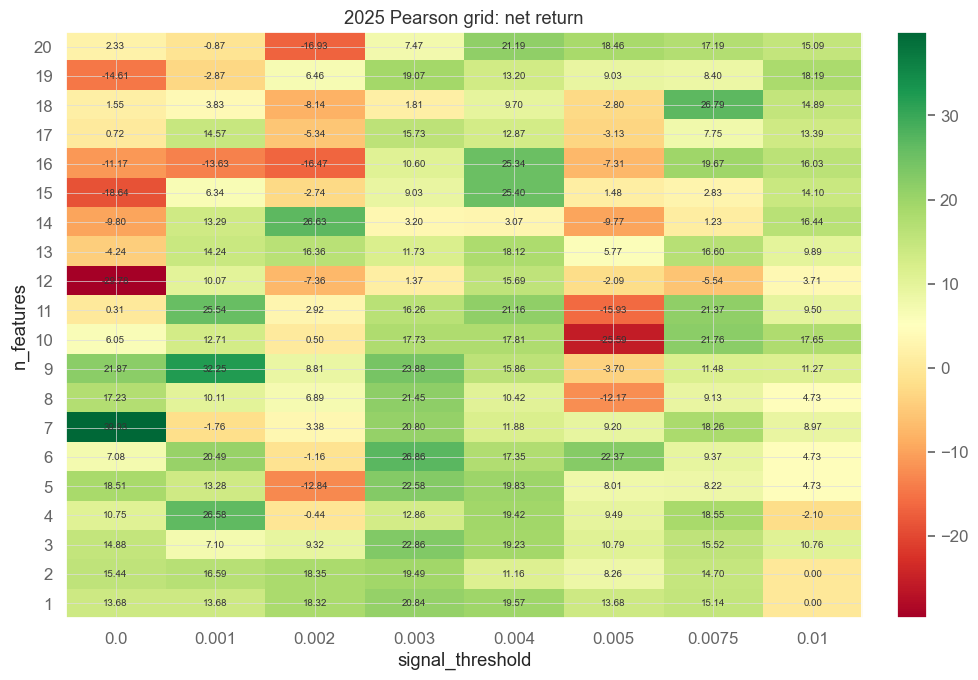

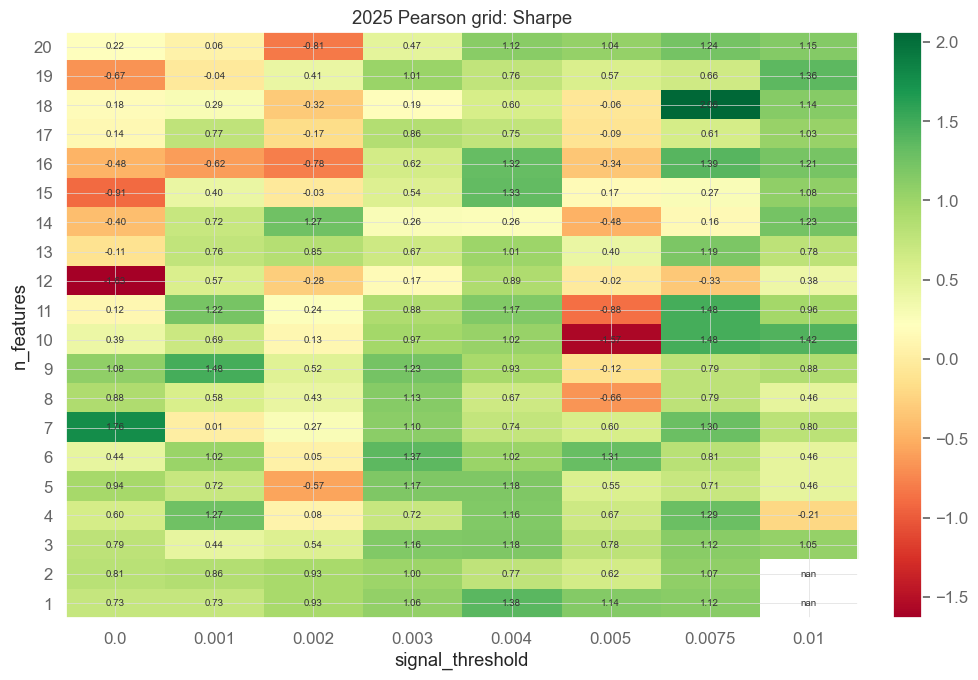

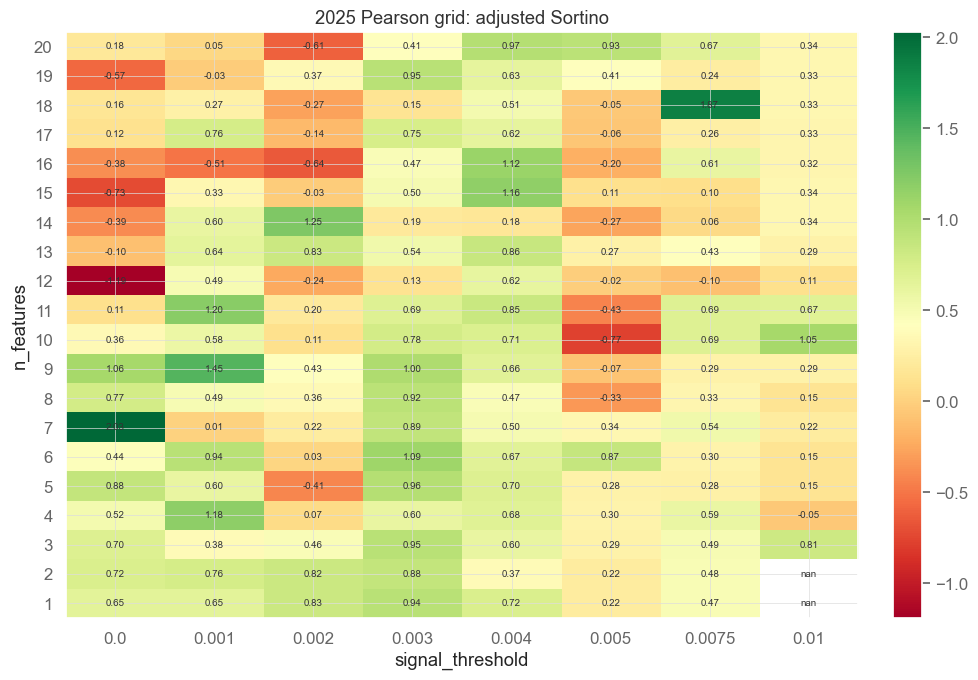

In [9]:
def plot_metric_grid(metrics_df: pd.DataFrame, metric: str, title: str | None = None):
    pivot = (
        metrics_df
        .pivot(index="n_features", columns="signal_threshold", values=metric)
        .sort_index(ascending=False)
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
    ax.set_title(title or metric)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("signal_threshold")
    ax.set_ylabel("n_features")

    for y in range(pivot.shape[0]):
        for x in range(pivot.shape[1]):
            value = pivot.values[y, x]
            label = "nan" if pd.isna(value) else f"{value:.2f}"
            ax.text(x, y, label, ha="center", va="center", fontsize=7)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_core_heatmaps(metrics_df: pd.DataFrame, title_prefix: str):
    plot_metric_grid(metrics_df, "net_return_pct", f"{title_prefix}: net return")
    plot_metric_grid(metrics_df, "net_sharpe", f"{title_prefix}: Sharpe")
    plot_metric_grid(metrics_df, "adjusted_net_sortino", f"{title_prefix}: adjusted Sortino")


plot_core_heatmaps(metrics_df, "2025 Pearson grid")

### Feature Diagnostics for Candidate Runs


After the grid finishes, this section inspects the feature-selection behavior of the top three Sharpe performers. This is the Pearson analogue of the PCA loading review: instead of component loadings, we look at how frequently each feature was selected and how strong its absolute Pearson score was across rolling training windows.

Top Sharpe performer #1: SPY_features-18_sig-0p0075


run_id,SPY_features-18_sig-0p0075
grid_index,142
symbol,SPY
n_features,18
signal_threshold,0.0075
training_years,10
start_date,2025-01-01
end_date,2026-01-01
gross_return_pct,27.265778
net_return_pct,26.79028
benchmark_return_pct,17.954018


,appearances,selected_appearances,mean_abs_corr,median_abs_corr,mean_rank,best_rank,selection_rate_pct
feature,,,,,,,
NATR_14,250,250,0.067,0.067,1.008,1,100.0
DD_LOG,250,250,0.059,0.060,3.152,2,100.0
DD_PCT,250,250,0.059,0.059,3.868,2,100.0
AVOLUME_20,250,250,0.056,0.056,7.292,4,100.0
HVOL_20,250,250,0.056,0.056,7.316,4,100.0
UI_14,250,250,0.055,0.054,9.376,4,100.0
RSI_14,250,238,0.053,0.052,12.512,4,95.2
CMO_14,250,235,0.053,0.052,12.360,4,94.0
ADOSC_3_10,250,231,0.056,0.056,8.720,2,92.4


Top Sharpe performer #2: SPY_features-7_sig-0


run_id,SPY_features-7_sig-0
grid_index,48
symbol,SPY
n_features,7
signal_threshold,0
training_years,10
start_date,2025-01-01
end_date,2026-01-01
gross_return_pct,41.013773
net_return_pct,39.934367
benchmark_return_pct,17.954018


,appearances,selected_appearances,mean_abs_corr,median_abs_corr,mean_rank,best_rank,selection_rate_pct
feature,,,,,,,
CDL_SHOOTINGSTAR,250,250,0.043,0.044,2.100,1,100.0
PSARaf_0.02_0.2,250,250,0.043,0.042,2.108,1,100.0
THERMOl_20_2_0.5,250,246,0.041,0.042,2.940,1,98.4
DD,250,181,0.037,0.038,8.240,3,72.4
CPR_WIDTH_PCT,250,171,0.038,0.037,5.560,1,68.4
CDL_HANGINGMAN,250,96,0.033,0.034,13.184,4,38.4
THERMOs_20_2_0.5,250,86,0.034,0.034,13.224,4,34.4
MAXIDX_30,250,79,0.031,0.033,26.056,5,31.6
MAXINDEX_30,250,66,0.031,0.033,26.152,5,26.4


Top Sharpe performer #3: SPY_features-9_sig-0p001


run_id,SPY_features-9_sig-0p001
grid_index,65
symbol,SPY
n_features,9
signal_threshold,0.001
training_years,10
start_date,2025-01-01
end_date,2026-01-01
gross_return_pct,32.733642
net_return_pct,32.254696
benchmark_return_pct,17.954018


,appearances,selected_appearances,mean_abs_corr,median_abs_corr,mean_rank,best_rank,selection_rate_pct
feature,,,,,,,
PSARaf_0.02_0.2,250,250,0.041,0.041,2.360,1,100.0
SQZPRO_ON_NARROW,250,250,0.040,0.040,2.808,1,100.0
CDL_3LINESTRIKE,250,250,0.036,0.036,5.600,4,100.0
CDL_SHOOTINGSTAR,250,236,0.039,0.040,3.332,1,94.4
THERMOl_20_2_0.5,250,218,0.040,0.041,3.872,1,87.2
CDL_LADDERBOTTOM,250,180,0.034,0.034,8.488,6,72.0
CPR_WIDTH_PCT,250,177,0.035,0.035,7.092,1,70.8
PSARr_0.02_0.2,250,115,0.032,0.033,10.992,4,46.0
CDL_ENGULFING,250,110,0.033,0.033,11.404,4,44.0


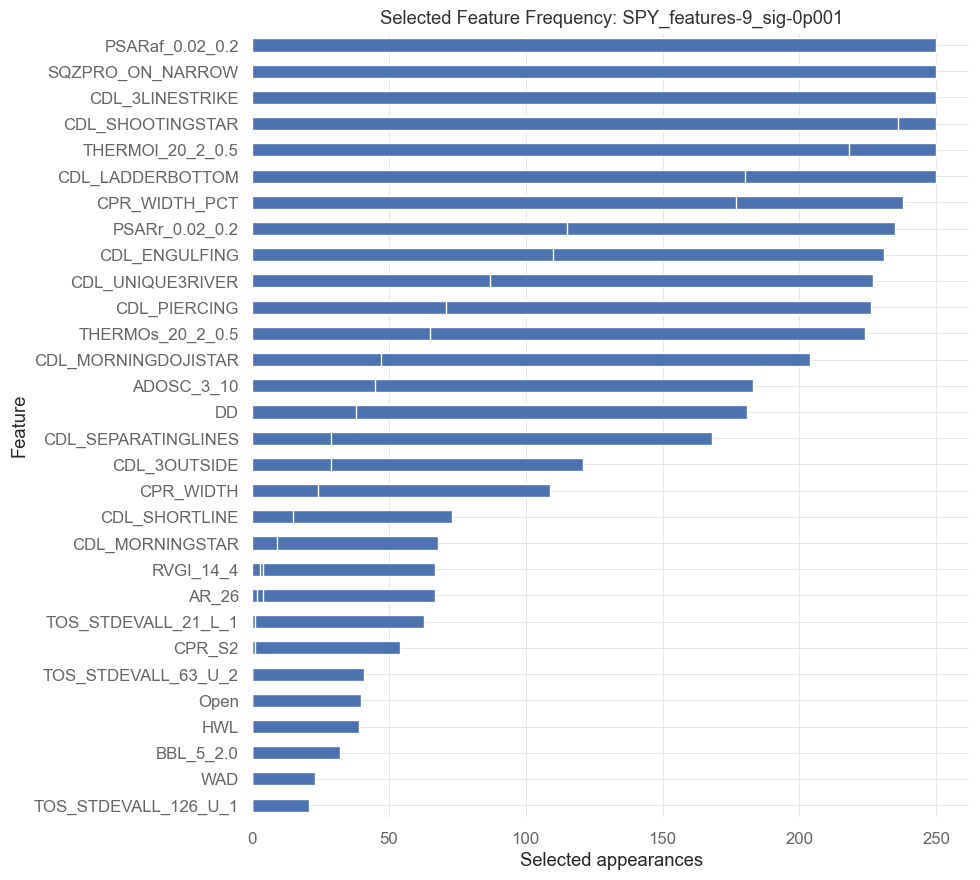

In [10]:
def show_top_feature_diagnostics(metrics_df: pd.DataFrame, grid_artifacts: dict, top_n_runs: int = 3, top_n_features: int = 40):
    top_run_ids = metrics_df.sort_values("net_sharpe", ascending=False).head(top_n_runs)["run_id"].tolist()

    for rank, run_id in enumerate(top_run_ids, start=1):
        artifacts = grid_artifacts[run_id]
        feature_summary = artifacts["feature_summary"]

        print(f"Top Sharpe performer #{rank}: {run_id}")
        display(pd.DataFrame([artifacts["metrics"]]).set_index("run_id").T)
        display(feature_summary.head(top_n_features).round(3))
        plot_selected_feature_frequency(feature_summary, top_n=30, title=f"Selected Feature Frequency: {run_id}")

    return top_run_ids


top_sharpe_run_ids = show_top_feature_diagnostics(metrics_df, grid_artifacts, top_n_runs=3)

In [11]:
def compare_feature_summaries(run_ids, grid_artifacts: dict, top_n: int = 40) -> pd.DataFrame:
    frames = []
    for run_id in run_ids:
        summary = grid_artifacts[run_id]["feature_summary"]
        if summary.empty:
            continue
        frame = summary[["selected_appearances", "selection_rate_pct", "mean_abs_corr", "mean_rank"]].copy()
        frame = frame.add_prefix(f"{run_id}__")
        frames.append(frame)

    if not frames:
        return pd.DataFrame()

    comparison = pd.concat(frames, axis=1).fillna(0)
    selected_cols = [col for col in comparison.columns if col.endswith("selected_appearances")]
    comparison["total_selected_appearances"] = comparison[selected_cols].sum(axis=1)
    return comparison.sort_values("total_selected_appearances", ascending=False).head(top_n)


feature_comparison = compare_feature_summaries(top_sharpe_run_ids, grid_artifacts, top_n=50)
display(feature_comparison.round(2))

,SPY_features-18_sig-0p0075__selected_appearances,SPY_features-18_sig-0p0075__selection_rate_pct,SPY_features-18_sig-0p0075__mean_abs_corr,SPY_features-18_sig-0p0075__mean_rank,SPY_features-7_sig-0__selected_appearances,SPY_features-7_sig-0__selection_rate_pct,SPY_features-7_sig-0__mean_abs_corr,SPY_features-7_sig-0__mean_rank,SPY_features-9_sig-0p001__selected_appearances,SPY_features-9_sig-0p001__selection_rate_pct,SPY_features-9_sig-0p001__mean_abs_corr,SPY_features-9_sig-0p001__mean_rank,total_selected_appearances
feature,,,,,,,,,,,,,
THERMOl_20_2_0.5,121,48.4,0.05,28.71,246,98.4,0.04,2.94,218,87.2,0.04,3.87,585
PSARaf_0.02_0.2,0,0.0,0.01,360.31,250,100.0,0.04,2.11,250,100.0,0.04,2.36,500
CDL_SHOOTINGSTAR,0,0.0,0.01,295.31,250,100.0,0.04,2.10,236,94.4,0.04,3.33,486
CPR_WIDTH_PCT,0,0.0,0.03,101.43,171,68.4,0.04,5.56,177,70.8,0.04,7.09,348
CDL_ENGULFING,183,73.2,0.05,17.94,5,2.0,0.03,36.24,110,44.0,0.03,11.40,298
ADOSC_3_10,231,92.4,0.06,8.72,0,0.0,0.02,209.91,45,18.0,0.03,21.81,276
CDL_3LINESTRIKE,0,0.0,0.02,169.03,19,7.6,0.03,11.80,250,100.0,0.04,5.60,269
DD_PCT,250,100.0,0.06,3.87,1,0.4,0.03,83.12,0,0.0,0.02,82.77,251
DD_LOG,250,100.0,0.06,3.15,0,0.0,0.02,93.17,0,0.0,0.02,104.02,250


## Combined Strategy: Top 10 Net-Return Performers in 2025



This cell builds an equal-weight combined strategy from the top 10 Pearson grid performers ranked by `net_return_pct` in the 2025 candidate search. Each component strategy is rerun with `position_size=0.1`, the resulting target weights are summed into one combined SPY signal, and the combined portfolio is backtested as a single strategy.


📊 --- QUICK PORTFOLIO RESULTS: SPY Pearson Combined Strategy: Top 10 Net-Return Performers in 2025 ---
   Frictionless Return:     29.78%
   Net Strategy Return:     29.02%  (EW Benchmark: 17.95%)
   Max Drawdown:            -10.71%
   Win Rate (Gross Bars):   57.8%   (EW Benchmark: 56.6%)
   Loss Rate (Gross Bars):  41.0%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  1.2%    (EW Benchmark: 0.4%)
   Sharpe Ratio (Net):      1.79    (EW Benchmark: 0.92)
   Sortino/√2 (Net):        2.45    (EW Benchmark: 0.97)
   Total Fees Paid:         $7,613.44
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/SPY_Pearson_Combined_Strategy:_Top_10_Net-Return_Performers_in_2025_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


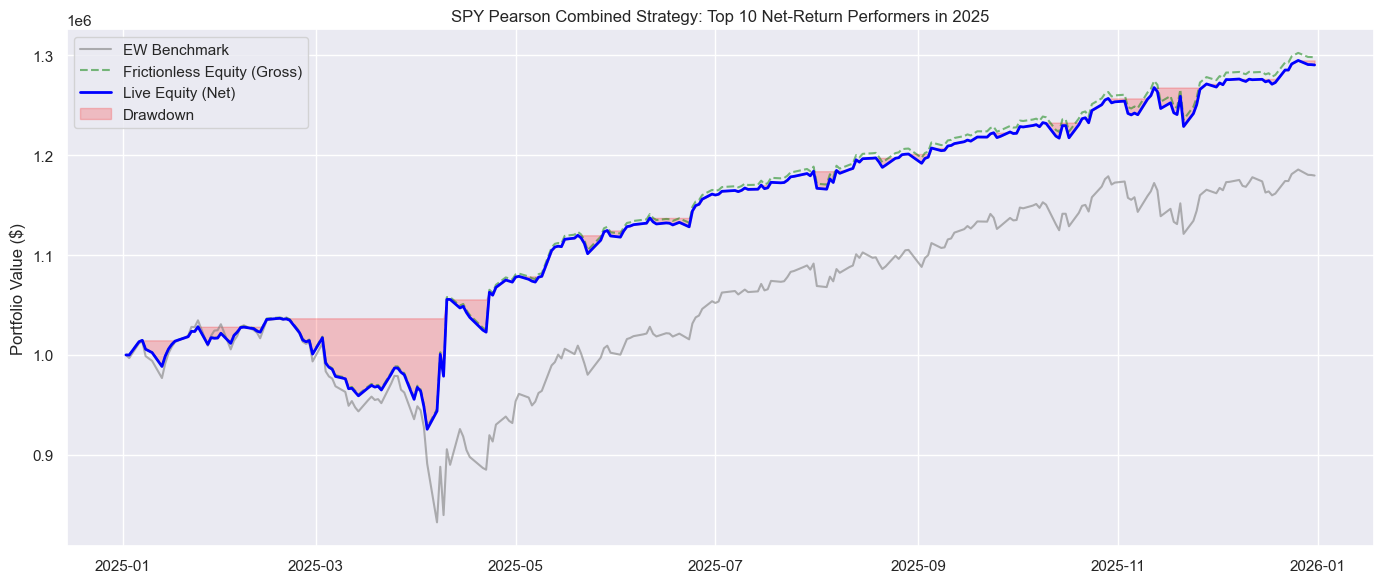

,grid_index,run_id,n_features,signal_threshold,position_size
0,48,SPY_features-7_sig-0,7,0.0000,0.1
1,65,SPY_features-9_sig-0p001,9,0.0010,0.1
2,43,SPY_features-6_sig-0p003,6,0.0030,0.1
3,142,SPY_features-18_sig-0p0075,18,0.0075,0.1
4,106,SPY_features-14_sig-0p002,14,0.0020,0.1
5,25,SPY_features-4_sig-0p001,4,0.0010,0.1
6,81,SPY_features-11_sig-0p001,11,0.0010,0.1
7,116,SPY_features-15_sig-0p004,15,0.0040,0.1
8,124,SPY_features-16_sig-0p004,16,0.0040,0.1
9,67,SPY_features-9_sig-0p003,9,0.0030,0.1


,SPY_features-7_sig-0,SPY_features-9_sig-0p001,SPY_features-6_sig-0p003,SPY_features-18_sig-0p0075,SPY_features-14_sig-0p002,SPY_features-4_sig-0p001,SPY_features-11_sig-0p001,SPY_features-15_sig-0p004,SPY_features-16_sig-0p004,SPY_features-9_sig-0p003
Timestamp,,,,,,,,,,
2025-01-02,0.1,0.1,0.1,0.0,0.1,0.1,0.1,0.1,0.1,0.1
2025-01-03,0.1,0.1,0.1,0.0,0.1,0.1,0.1,0.0,0.0,0.1
2025-01-06,0.1,0.1,0.0,0.0,0.1,0.1,0.1,0.1,0.0,0.0
2025-01-07,0.1,0.1,0.1,0.0,0.1,0.1,0.1,0.0,0.0,0.1
2025-01-08,0.1,0.1,0.1,0.0,0.1,0.1,0.1,0.0,0.1,0.1


,SPY
Timestamp,
2025-01-02,0.9
2025-01-03,0.7
2025-01-06,0.6
2025-01-07,0.7
2025-01-08,0.8


,gross_returns,gross_equity,total_costs_usd,cumulative_costs,net_equity,net_returns,cum_benchmark
Timestamp,,,,,,,
2025-12-24,0.004714,1.298710e+06,17.451823,7550.902016,1.291159e+06,0.004728,1.180931
2025-12-26,0.002737,1.302265e+06,0.486544,7551.388561,1.294713e+06,0.002753,1.185548
2025-12-29,-0.003142,1.298173e+06,34.402262,7585.790822,1.290587e+06,-0.003187,1.180227
2025-12-30,-0.000065,1.298088e+06,0.354247,7586.145069,1.290502e+06,-0.000066,1.180072
2025-12-31,-0.000225,1.297795e+06,27.293370,7613.438438,1.290182e+06,-0.000248,1.179540


In [12]:
from src.vector_backtester_Mateo import PortfolioVectorEngine

top_10_return_rows = metrics_df.sort_values("net_return_pct", ascending=False).head(10)

combined_specs_2025_top10 = []
for grid_index, row in top_10_return_rows.iterrows():
    combined_specs_2025_top10.append({
        "grid_index": grid_index,
        "run_id": row["run_id"],
        "n_features": int(row["n_features"]),
        "signal_threshold": float(row["signal_threshold"]),
        "position_size": 0.1,
    })

combined_artifacts_2025_top10 = {}
combined_weights_parts_2025_top10 = []

for spec in combined_specs_2025_top10:
    run_id = spec["run_id"]

    artifacts = run_single_case_features_capture(
        symbol=SYMBOL,
        asset_class=ASSET_CLASS,
        start_date=COMMON_PARAMS_2025["start_date"],
        end_date=COMMON_PARAMS_2025["end_date"],
        signal_threshold=spec["signal_threshold"],
        n_features=spec["n_features"],
        training_years=COMMON_PARAMS_2025["training_years"],
        sharpe_filter_enabled=COMMON_PARAMS_2025["sharpe_filter_enabled"],
        feature_diagnostics_enabled=COMMON_PARAMS_2025["feature_diagnostics_enabled"],
        feature_diagnostics_top_n=COMMON_PARAMS_2025["feature_diagnostics_top_n"],
        position_size=spec["position_size"],
        initial_capital=INITIAL_CAPITAL,
        max_iter=COMMON_PARAMS_2025["max_iter"],
        execution_delay=EXECUTION_DELAY,
        verbose=COMMON_PARAMS_2025["verbose"],
        show_progress=SHOW_PROGRESS,
        show_tearsheet=False,
    )

    combined_artifacts_2025_top10[run_id] = artifacts
    combined_weights_parts_2025_top10.append(
        artifacts["weights"].rename(columns={SYMBOL: run_id})
    )

combined_component_weights_2025_top10 = pd.concat(combined_weights_parts_2025_top10, axis=1).fillna(0)

combined_weights_2025_top10 = pd.DataFrame(
    {SYMBOL: combined_component_weights_2025_top10.sum(axis=1)},
    index=combined_component_weights_2025_top10.index,
)

combined_prices_2025_top10 = (
    next(iter(combined_artifacts_2025_top10.values()))["prices"]
    .loc[combined_weights_2025_top10.index]
)

combined_engine_2025_top10 = PortfolioVectorEngine(
    prices=combined_prices_2025_top10,
    signals=combined_weights_2025_top10,
    asset_class=ASSET_CLASS,
    initial_capital=INITIAL_CAPITAL,
    execution_delay=EXECUTION_DELAY,
)

combined_stats_2025_top10 = combined_engine_2025_top10.run()
combined_engine_2025_top10.tearsheet("SPY Pearson Combined Strategy: Top 10 Net-Return Performers in 2025")

combined_strategy_2025_top10 = {
    "symbol": SYMBOL,
    "specs": combined_specs_2025_top10,
    "component_artifacts": combined_artifacts_2025_top10,
    "component_weights": combined_component_weights_2025_top10,
    "weights": combined_weights_2025_top10,
    "prices": combined_prices_2025_top10,
    "engine": combined_engine_2025_top10,
    "stats": combined_stats_2025_top10,
}

display(pd.DataFrame(combined_specs_2025_top10))
display(combined_component_weights_2025_top10.head())
display(combined_weights_2025_top10.head())
display(combined_stats_2025_top10.tail())

Now test how this combined strategy would work on `2026 – YTD`


📊 --- QUICK PORTFOLIO RESULTS: SPY Pearson Combined Strategy: Top 10 Net-Return Performers in 2025 ---
   Frictionless Return:     6.53%
   Net Strategy Return:     6.21%  (EW Benchmark: 8.68%)
   Max Drawdown:            -4.04%
   Win Rate (Gross Bars):   51.6%   (EW Benchmark: 54.9%)
   Loss Rate (Gross Bars):  44.3%   (EW Benchmark: 45.1%)
   Zero Rate (Gross Bars):  4.1%    (EW Benchmark: 0.0%)
   Sharpe Ratio (Net):      1.35    (EW Benchmark: 1.34)
   Sortino/√2 (Net):        1.52    (EW Benchmark: 1.45)
   Total Fees Paid:         $3,190.20
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/SPY_Pearson_Combined_Strategy:_Top_10_Net-Return_Performers_in_2025_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


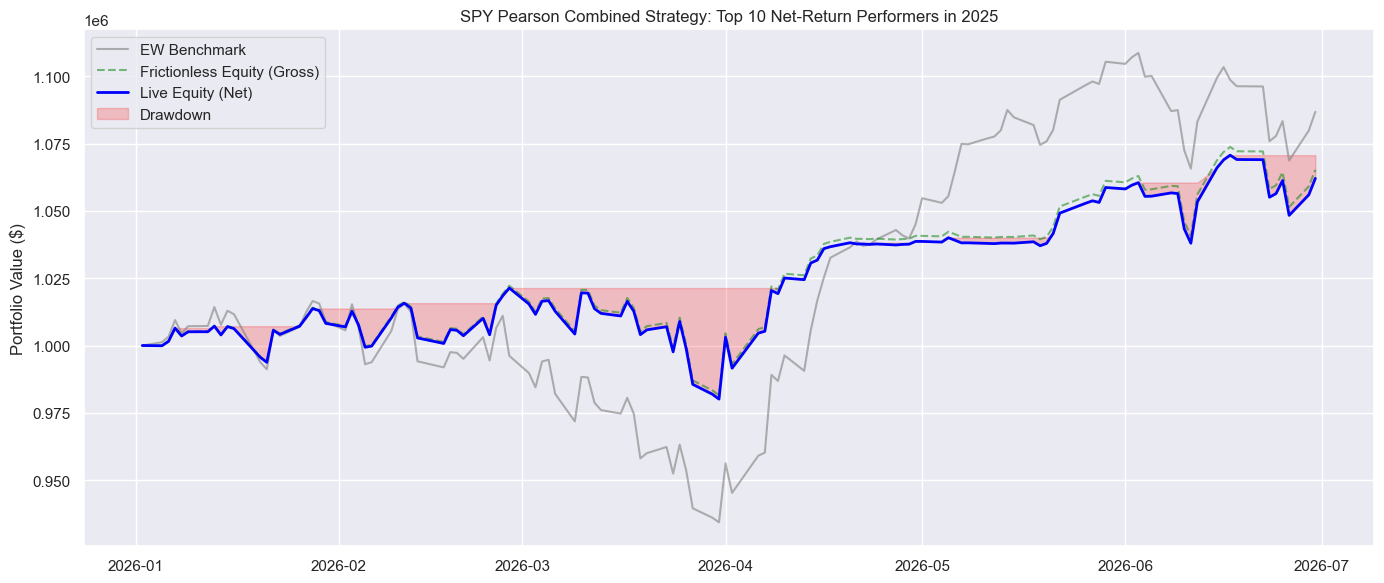

,grid_index,run_id,n_features,signal_threshold,position_size
0,48,SPY_features-7_sig-0,7,0.0000,0.1
1,65,SPY_features-9_sig-0p001,9,0.0010,0.1
2,43,SPY_features-6_sig-0p003,6,0.0030,0.1
3,142,SPY_features-18_sig-0p0075,18,0.0075,0.1
4,106,SPY_features-14_sig-0p002,14,0.0020,0.1
5,25,SPY_features-4_sig-0p001,4,0.0010,0.1
6,81,SPY_features-11_sig-0p001,11,0.0010,0.1
7,116,SPY_features-15_sig-0p004,15,0.0040,0.1
8,124,SPY_features-16_sig-0p004,16,0.0040,0.1
9,67,SPY_features-9_sig-0p003,9,0.0030,0.1


,SPY_features-7_sig-0,SPY_features-9_sig-0p001,SPY_features-6_sig-0p003,SPY_features-18_sig-0p0075,SPY_features-14_sig-0p002,SPY_features-4_sig-0p001,SPY_features-11_sig-0p001,SPY_features-15_sig-0p004,SPY_features-16_sig-0p004,SPY_features-9_sig-0p003
Timestamp,,,,,,,,,,
2026-01-02,0.1,0.1,0.1,0.0,0.1,0.1,0.1,0.0,0.1,0.1
2026-01-05,0.1,0.1,0.1,0.0,0.1,0.1,0.1,0.0,0.1,0.1
2026-01-06,0.1,0.1,0.1,0.0,0.1,0.1,0.1,0.0,0.0,0.0
2026-01-07,0.1,0.1,0.1,0.0,0.1,0.1,0.1,0.0,0.0,0.0
2026-01-08,0.1,0.1,0.0,0.0,0.1,0.1,0.1,0.0,0.0,0.0


,SPY
Timestamp,
2026-01-02,0.8
2026-01-05,0.8
2026-01-06,0.6
2026-01-07,0.6
2026-01-08,0.5


,gross_returns,gross_equity,total_costs_usd,cumulative_costs,net_equity,net_returns,cum_benchmark
Timestamp,,,,,,,
2026-06-24,0.001297,1.059500e+06,22.155672,3083.434352,1.056417e+06,0.001280,1.077827
2026-06-25,0.004579,1.064351e+06,0.412104,3083.846456,1.061267e+06,0.004591,1.083310
2026-06-26,-0.012131,1.051439e+06,27.760841,3111.607296,1.048327e+06,-0.012193,1.068708
2026-06-29,0.007279,1.059092e+06,21.947899,3133.555195,1.055959e+06,0.007280,1.079821
2026-06-30,0.005816,1.065252e+06,56.644734,3190.199929,1.062062e+06,0.005780,1.086800


In [13]:
from src.vector_backtester_Mateo import PortfolioVectorEngine

top_10_return_rows = metrics_df.sort_values("net_return_pct", ascending=False).head(10)

combined_specs_2025_top10 = []
for grid_index, row in top_10_return_rows.iterrows():
    combined_specs_2025_top10.append({
        "grid_index": grid_index,
        "run_id": row["run_id"],
        "n_features": int(row["n_features"]),
        "signal_threshold": float(row["signal_threshold"]),
        "position_size": 0.1,
    })

combined_artifacts_2025_top10 = {}
combined_weights_parts_2025_top10 = []

for spec in combined_specs_2025_top10:
    run_id = spec["run_id"]

    artifacts = run_single_case_features_capture(
        symbol=SYMBOL,
        asset_class=ASSET_CLASS,
        # start_date=COMMON_PARAMS_2025["start_date"],
        start_date="2026-01-01",
        # end_date=COMMON_PARAMS_2025["end_date"],
        end_date="2026-07-01",
        signal_threshold=spec["signal_threshold"],
        n_features=spec["n_features"],
        training_years=COMMON_PARAMS_2025["training_years"],
        sharpe_filter_enabled=COMMON_PARAMS_2025["sharpe_filter_enabled"],
        feature_diagnostics_enabled=COMMON_PARAMS_2025["feature_diagnostics_enabled"],
        feature_diagnostics_top_n=COMMON_PARAMS_2025["feature_diagnostics_top_n"],
        position_size=spec["position_size"],
        initial_capital=INITIAL_CAPITAL,
        max_iter=COMMON_PARAMS_2025["max_iter"],
        execution_delay=EXECUTION_DELAY,
        verbose=COMMON_PARAMS_2025["verbose"],
        show_progress=SHOW_PROGRESS,
        show_tearsheet=False,
    )

    combined_artifacts_2025_top10[run_id] = artifacts
    combined_weights_parts_2025_top10.append(
        artifacts["weights"].rename(columns={SYMBOL: run_id})
    )

combined_component_weights_2025_top10 = pd.concat(combined_weights_parts_2025_top10, axis=1).fillna(0)

combined_weights_2025_top10 = pd.DataFrame(
    {SYMBOL: combined_component_weights_2025_top10.sum(axis=1)},
    index=combined_component_weights_2025_top10.index,
)

combined_prices_2025_top10 = (
    next(iter(combined_artifacts_2025_top10.values()))["prices"]
    .loc[combined_weights_2025_top10.index]
)

combined_engine_2025_top10 = PortfolioVectorEngine(
    prices=combined_prices_2025_top10,
    signals=combined_weights_2025_top10,
    asset_class=ASSET_CLASS,
    initial_capital=INITIAL_CAPITAL,
    execution_delay=EXECUTION_DELAY,
)

combined_stats_2025_top10 = combined_engine_2025_top10.run()
combined_engine_2025_top10.tearsheet("SPY Pearson Combined Strategy: Top 10 Net-Return Performers in 2025")

combined_strategy_2025_top10 = {
    "symbol": SYMBOL,
    "specs": combined_specs_2025_top10,
    "component_artifacts": combined_artifacts_2025_top10,
    "component_weights": combined_component_weights_2025_top10,
    "weights": combined_weights_2025_top10,
    "prices": combined_prices_2025_top10,
    "engine": combined_engine_2025_top10,
    "stats": combined_stats_2025_top10,
}

display(pd.DataFrame(combined_specs_2025_top10))
display(combined_component_weights_2025_top10.head())
display(combined_weights_2025_top10.head())
display(combined_stats_2025_top10.tail())

Seems like this combined strategy would perform terribly out of sample :(

## Second Candidate Search: Test Top Combined Strategy For 2023-2025 On 2026-YTD

This duplicates the Pearson grid-search workflow for a longer candidate-selection window: `2023-01-01` to `2026-01-01`. The purpose is to find parameter sets that performed well across 2023-2025 before we later test selected combined-strategy candidates on 2026-YTD data.

### 2023-2025 Grid search

In [14]:
metrics_df_2023_2025, errors_df_2023_2025, grid_artifacts_2023_2025 = run_grid_search(
    COMMON_PARAMS_2023_2025,
    OUTPUT_DIR_2023_2025,
)
show_leaderboards(
    metrics_df_2023_2025,
    errors_df_2023_2025,
    title="Test top combined strategy for 2023-2025 on 2026-YTD",
)

Total cases: 160


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.


Running grid_index=0: SPY_features-1_sig-0
Running grid_index=2: SPY_features-1_sig-0p002
Running grid_index=5: SPY_features-1_sig-0p005
Running grid_index=7: SPY_features-1_sig-0p01
Running grid_index=8: SPY_features-2_sig-0
Running grid_index=6: SPY_features-1_sig-0p0075
Running grid_index=4: SPY_features-1_sig-0p004
Running grid_index=11: SPY_features-2_sig-0p003
Running grid_index=3: SPY_features-1_sig-0p003
Running grid_index=9: SPY_features-2_sig-0p001
Running grid_index=10: SPY_features-2_sig-0p002
Running grid_index=12: SPY_features-2_sig-0p004
Running grid_index=1: SPY_features-1_sig-0p001
Running grid_index=13: SPY_features-2_sig-0p005
Running grid_index=14: SPY_features-2_sig-0p0075
Running grid_index=15: SPY_features-2_sig-0p01
Running grid_index=16: SPY_features-3_sig-0


[Parallel(n_jobs=15)]: Done   2 tasks      | elapsed:  5.2min


Running grid_index=17: SPY_features-3_sig-0p001
Running grid_index=18: SPY_features-3_sig-0p002
Running grid_index=19: SPY_features-3_sig-0p003
Running grid_index=20: SPY_features-3_sig-0p004
Running grid_index=21: SPY_features-3_sig-0p005
Running grid_index=22: SPY_features-3_sig-0p0075
Running grid_index=23: SPY_features-3_sig-0p01
Running grid_index=24: SPY_features-4_sig-0
Running grid_index=25: SPY_features-4_sig-0p001


...

Top by net return


,run_id,n_features,signal_threshold,net_sharpe,adjusted_net_sortino,net_return_pct,gross_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,total_fees_paid,active_days_pct,average_abs_exposure,average_daily_turnover,gross_win_rate_pct,gross_loss_rate_pct,gross_zero_return_rate_pct,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,diagnostic_rows,unique_selected_features,mean_selected_abs_corr
grid_index,,,,,,,,,,,,,,,,,,,,,,
65,SPY_features-9_sig-0p001,9,0.0,1.62,1.60,108.25,110.35,22.28,-15.85,21024.80,100.00,1.00,0.16,55.79,43.81,0.40,6.12,0.00,93.88,320347,30,0.04
106,SPY_features-14_sig-0p002,14,0.0,1.42,1.39,89.63,94.96,3.65,-10.61,53376.20,94.95,0.95,0.40,53.00,41.54,5.46,12.23,5.05,82.71,320347,41,0.04
48,SPY_features-7_sig-0,7,0.0,1.38,1.50,85.94,88.54,-0.03,-17.32,25937.35,100.00,1.00,0.21,53.66,45.94,0.40,8.24,0.00,91.76,320347,39,0.04
81,SPY_features-11_sig-0p001,11,0.0,1.35,1.34,83.22,85.69,-2.76,-16.60,24726.58,100.00,1.00,0.20,55.53,44.07,0.40,6.65,0.00,93.35,320347,36,0.04
98,SPY_features-13_sig-0p002,13,0.0,1.34,1.30,82.37,86.56,-3.61,-11.53,41882.08,97.07,0.97,0.31,54.19,42.48,3.33,10.24,2.93,86.84,320347,40,0.04
2,SPY_features-1_sig-0p002,1,0.0,1.34,1.24,81.52,81.59,-4.45,-19.77,675.80,100.00,1.00,0.01,55.13,44.47,0.40,0.13,0.00,99.87,320347,10,0.05
32,SPY_features-5_sig-0,5,0.0,1.32,1.27,80.76,82.87,-5.22,-15.99,21118.53,100.00,1.00,0.16,54.59,45.01,0.40,5.98,0.00,94.02,320347,28,0.04
10,SPY_features-2_sig-0p002,2,0.0,1.30,1.21,78.45,78.96,-7.53,-20.64,5102.81,100.00,1.00,0.04,55.26,44.34,0.40,1.06,0.00,98.94,320347,15,0.05
16,SPY_features-3_sig-0,3,0.0,1.27,1.18,75.96,76.66,-10.01,-19.82,6963.09,100.00,1.00,0.06,54.73,44.87,0.40,1.60,0.00,98.40,320347,17,0.04


Best drawdown control
Note: drawdown ranking excludes runs with active_days_pct < 1%, because almost-never-trading runs can make drawdown look artificially good.


,run_id,n_features,signal_threshold,net_sharpe,adjusted_net_sortino,net_return_pct,gross_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,total_fees_paid,active_days_pct,average_abs_exposure,average_daily_turnover,gross_win_rate_pct,gross_loss_rate_pct,gross_zero_return_rate_pct,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,diagnostic_rows,unique_selected_features,mean_selected_abs_corr
grid_index,,,,,,,,,,,,,,,,,,,,,,
142,SPY_features-18_sig-0p0075,18,0.01,1.23,0.72,28.52,29.12,-57.45,-2.37,6041.89,4.12,0.04,0.06,2.53,1.60,95.87,1.60,95.88,2.53,320347,44,0.06
79,SPY_features-10_sig-0p01,10,0.01,0.82,0.35,17.65,17.73,-68.32,-3.69,801.47,1.20,0.01,0.01,0.53,0.67,98.80,0.00,98.80,1.20,320347,23,0.08
87,SPY_features-11_sig-0p01,11,0.01,0.55,0.22,9.50,9.52,-76.48,-4.40,254.62,1.20,0.01,0.00,0.40,0.80,98.80,0.00,98.80,1.20,320347,27,0.08
23,SPY_features-3_sig-0p01,3,0.01,0.61,0.27,10.76,10.78,-75.22,-4.40,256.23,1.46,0.01,0.00,0.53,0.93,98.54,0.00,98.54,1.46,320347,7,0.08
119,SPY_features-15_sig-0p01,15,0.01,0.62,0.11,14.10,14.18,-71.87,-5.45,794.64,1.20,0.01,0.01,0.53,0.67,98.80,0.00,98.80,1.20,320347,35,0.07
71,SPY_features-9_sig-0p01,9,0.01,0.50,0.10,11.27,11.32,-74.71,-5.45,519.52,1.33,0.01,0.01,0.53,0.80,98.67,0.00,98.67,1.33,320347,20,0.08
6,SPY_features-1_sig-0p0075,1,0.01,0.65,0.16,15.14,15.19,-70.83,-5.45,518.52,2.93,0.03,0.01,1.46,1.46,97.07,0.00,97.07,2.93,320347,2,0.07
143,SPY_features-18_sig-0p01,18,0.01,0.65,0.11,14.89,14.97,-71.08,-5.45,795.65,1.06,0.01,0.01,0.53,0.53,98.93,0.00,98.94,1.06,320347,39,0.07
135,SPY_features-17_sig-0p01,17,0.01,0.59,0.11,13.39,13.49,-72.59,-5.45,1053.75,1.06,0.01,0.01,0.53,0.53,98.93,0.00,98.94,1.06,320347,38,0.07


""


### 2023-2025 Heatmaps

The same core heatmaps are shown for the longer window: net return, Sharpe, and adjusted Sortino.

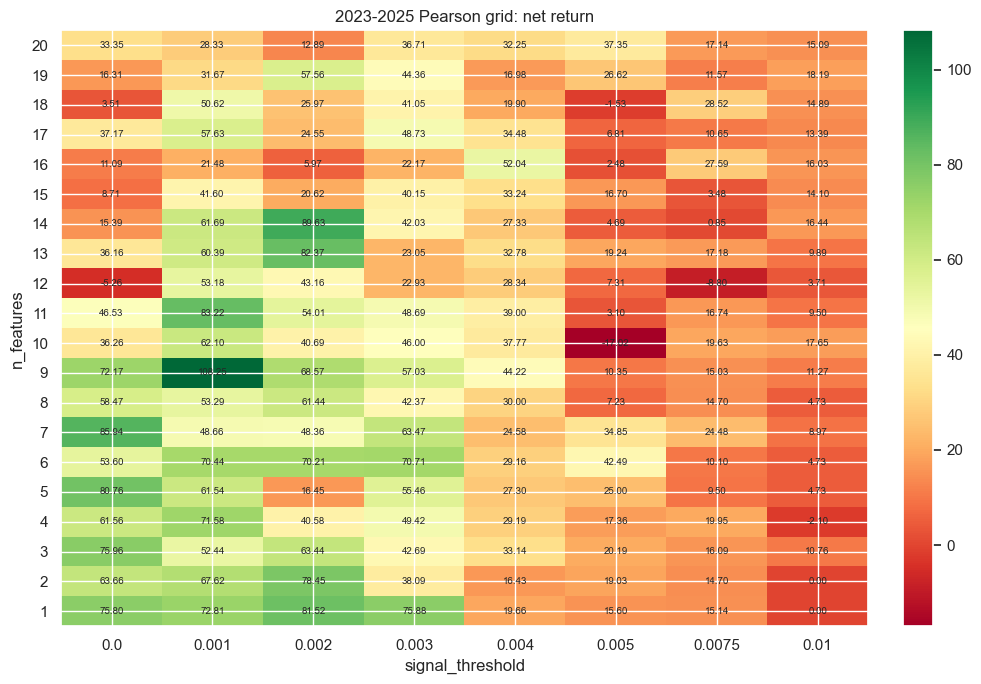

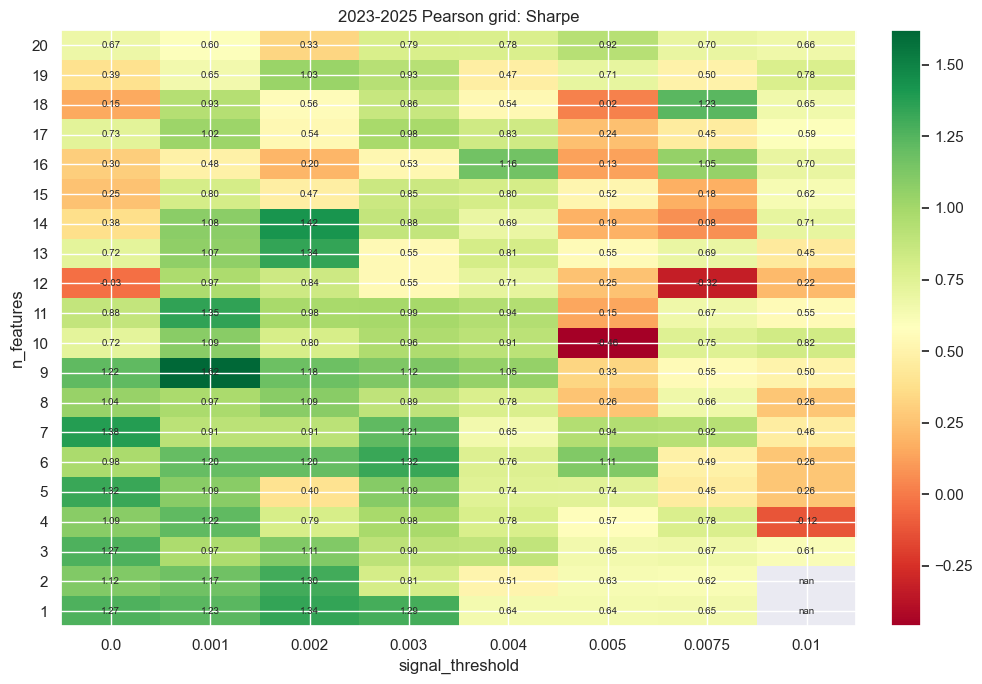

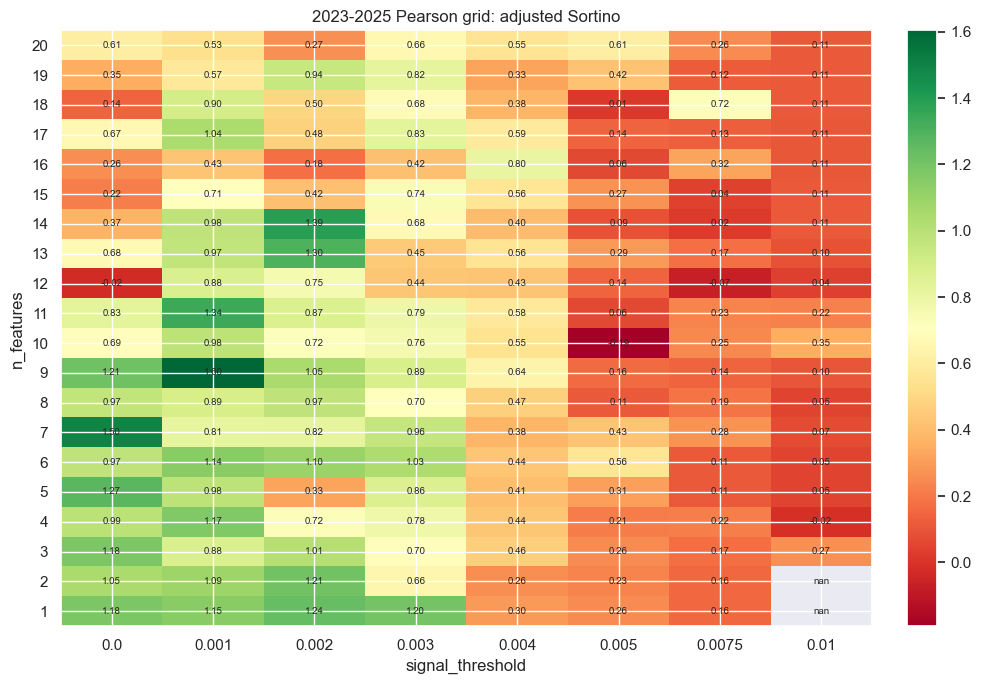

In [15]:
plot_core_heatmaps(metrics_df_2023_2025, "2023-2025 Pearson grid")

### 2023-2025 Feature Diagnostics For Top Sharpe Performers

These diagnostics inspect the top three Sharpe performers in the longer candidate-selection window.

Top Sharpe performer #1: SPY_features-9_sig-0p001


run_id,SPY_features-9_sig-0p001
grid_index,65
symbol,SPY
n_features,9
signal_threshold,0.001
training_years,10
start_date,2023-01-01
end_date,2026-01-01
gross_return_pct,110.351631
net_return_pct,108.249151
benchmark_return_pct,85.974098


,appearances,selected_appearances,mean_abs_corr,median_abs_corr,mean_rank,best_rank,selection_rate_pct
feature,,,,,,,
SQZPRO_ON_NARROW,752,732,0.039,0.039,4.499,1,97.340
PSARaf_0.02_0.2,752,572,0.037,0.038,7.947,1,76.064
CDL_3LINESTRIKE,752,528,0.035,0.036,9.195,4,70.213
CDL_ENGULFING,752,511,0.037,0.036,7.562,1,67.952
CDL_LADDERBOTTOM,752,473,0.036,0.034,7.544,1,62.899
PSARr_0.02_0.2,752,468,0.035,0.036,8.562,1,62.234
CDL_MORNINGDOJISTAR,752,447,0.036,0.041,16.258,1,59.441
CDL_3OUTSIDE,752,439,0.035,0.035,10.617,1,58.378
CPR_WIDTH_PCT,752,414,0.035,0.035,11.890,1,55.053


Top Sharpe performer #2: SPY_features-14_sig-0p002


run_id,SPY_features-14_sig-0p002
grid_index,106
symbol,SPY
n_features,14
signal_threshold,0.002
training_years,10
start_date,2023-01-01
end_date,2026-01-01
gross_return_pct,94.964641
net_return_pct,89.627021
benchmark_return_pct,85.974098


,appearances,selected_appearances,mean_abs_corr,median_abs_corr,mean_rank,best_rank,selection_rate_pct
feature,,,,,,,
ADOSC_3_10,752,742,0.043,0.044,4.055,1,98.670
CPR_WIDTH_PCT,752,731,0.042,0.043,5.551,1,97.207
CDL_LADDERBOTTOM,752,692,0.039,0.036,9.315,2,92.021
CDL_ENGULFING,752,685,0.041,0.040,7.004,1,91.090
CDL_MORNINGDOJISTAR,752,574,0.038,0.044,19.279,1,76.330
PSARaf_0.02_0.2,752,571,0.041,0.042,9.158,1,75.931
AR_26,752,553,0.039,0.039,9.403,1,73.537
CDL_3LINESTRIKE,752,544,0.037,0.038,12.820,4,72.340
CPR_WIDTH,752,527,0.038,0.039,13.364,1,70.080


Top Sharpe performer #3: SPY_features-7_sig-0


run_id,SPY_features-7_sig-0
grid_index,48
symbol,SPY
n_features,7
signal_threshold,0
training_years,10
start_date,2023-01-01
end_date,2026-01-01
gross_return_pct,88.538384
net_return_pct,85.944649
benchmark_return_pct,85.974098


,appearances,selected_appearances,mean_abs_corr,median_abs_corr,mean_rank,best_rank,selection_rate_pct
feature,,,,,,,
PSARaf_0.02_0.2,752,533,0.038,0.039,7.531,1,70.878
AR_26,752,462,0.035,0.036,27.815,1,61.436
CPR_WIDTH_PCT,752,436,0.037,0.038,11.275,1,57.979
CDL_MORNINGDOJISTAR,752,397,0.034,0.039,30.250,1,52.793
THERMOl_20_2_0.5,752,384,0.035,0.034,22.541,1,51.064
CDL_ENGULFING,752,343,0.035,0.033,16.805,1,45.612
CPR_WIDTH,752,314,0.034,0.035,30.188,1,41.755
INC_8,752,283,0.032,0.029,38.012,1,37.633
CDL_HANGINGMAN,752,273,0.034,0.034,10.537,1,36.303


,SPY_features-9_sig-0p001__selected_appearances,SPY_features-9_sig-0p001__selection_rate_pct,SPY_features-9_sig-0p001__mean_abs_corr,SPY_features-9_sig-0p001__mean_rank,SPY_features-14_sig-0p002__selected_appearances,SPY_features-14_sig-0p002__selection_rate_pct,SPY_features-14_sig-0p002__mean_abs_corr,SPY_features-14_sig-0p002__mean_rank,SPY_features-7_sig-0__selected_appearances,SPY_features-7_sig-0__selection_rate_pct,SPY_features-7_sig-0__mean_abs_corr,SPY_features-7_sig-0__mean_rank,total_selected_appearances
feature,,,,,,,,,,,,,
PSARaf_0.02_0.2,572,76.064,0.037,7.947,571,75.931,0.041,9.158,533,70.878,0.038,7.531,1676
CPR_WIDTH_PCT,414,55.053,0.035,11.890,731,97.207,0.042,5.551,436,57.979,0.037,11.275,1581
CDL_ENGULFING,511,67.952,0.037,7.562,685,91.090,0.041,7.004,343,45.612,0.035,16.805,1539
CDL_MORNINGDOJISTAR,447,59.441,0.036,16.258,574,76.330,0.038,19.279,397,52.793,0.034,30.250,1418
CDL_LADDERBOTTOM,473,62.899,0.036,7.544,692,92.021,0.039,9.315,239,31.782,0.034,12.838,1404
AR_26,343,45.612,0.034,13.051,553,73.537,0.039,9.403,462,61.436,0.035,27.815,1358
CDL_3LINESTRIKE,528,70.213,0.035,9.195,544,72.340,0.037,12.820,45,5.984,0.032,18.983,1117
CPR_WIDTH,247,32.846,0.032,19.328,527,70.080,0.038,13.364,314,41.755,0.034,30.188,1088
ADOSC_3_10,200,26.596,0.032,18.693,742,98.670,0.043,4.055,0,0.000,0.017,175.975,942


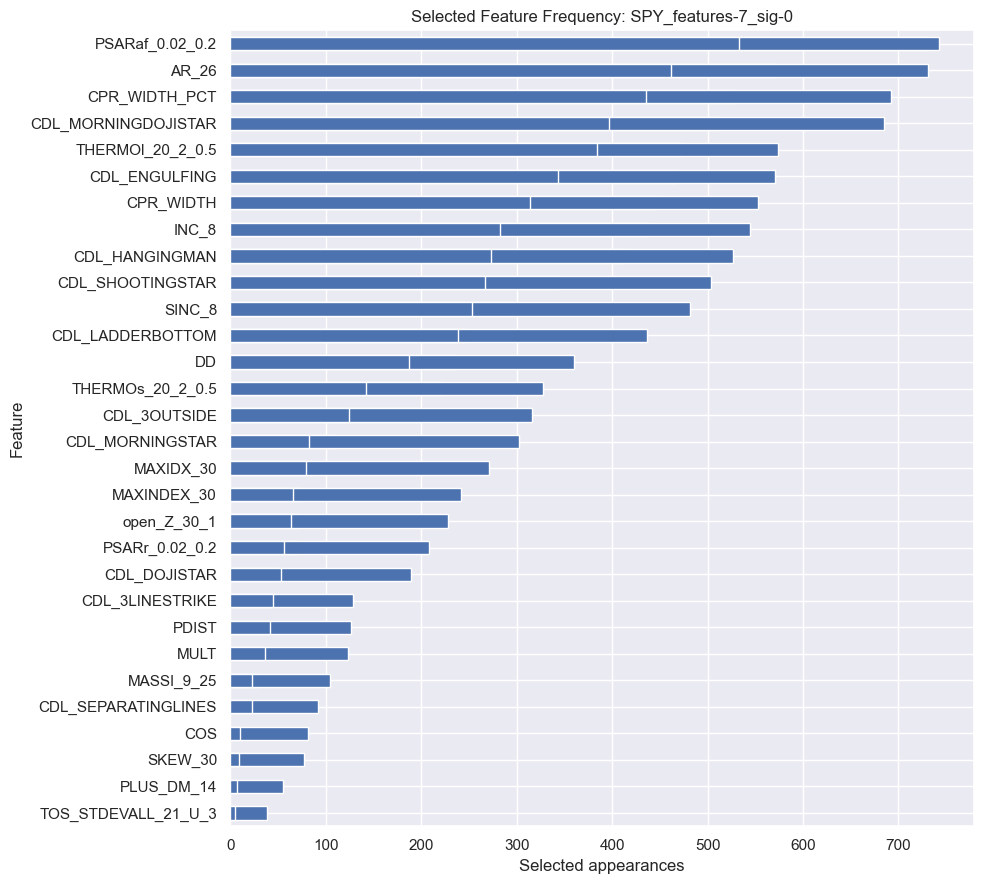

In [16]:
top_sharpe_run_ids_2023_2025 = show_top_feature_diagnostics(
    metrics_df_2023_2025,
    grid_artifacts_2023_2025,
    top_n_runs=3,
)

feature_comparison_2023_2025 = compare_feature_summaries(
    top_sharpe_run_ids_2023_2025,
    grid_artifacts_2023_2025,
    top_n=50,
)
display(feature_comparison_2023_2025.round(3))

## Combined Strategy: Top 10 Net-Return Performers in 2023-2025



This cell builds an equal-weight combined strategy from the top 10 Pearson grid performers ranked by `net_return_pct` in the 2023-2025 candidate search. Each component strategy is rerun with `position_size=0.1`, the resulting target weights are summed into one combined SPY signal, and the combined portfolio is backtested as a single strategy.


📊 --- QUICK PORTFOLIO RESULTS: SPY Pearson Combined Strategy: Top 10 Net-Return Performers in 2023-2025 ---
   Frictionless Return:     87.38%
   Net Strategy Return:     85.68%  (EW Benchmark: 85.97%)
   Max Drawdown:            -13.37%
   Win Rate (Gross Bars):   55.1%   (EW Benchmark: 55.3%)
   Loss Rate (Gross Bars):  43.9%   (EW Benchmark: 44.5%)
   Zero Rate (Gross Bars):  0.9%    (EW Benchmark: 0.3%)
   Sharpe Ratio (Net):      1.53    (EW Benchmark: 1.39)
   Sortino/√2 (Net):        1.67    (EW Benchmark: 1.46)
   Total Fees Paid:         $17,067.88
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/SPY_Pearson_Combined_Strategy:_Top_10_Net-Return_Performers_in_2023-2025_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


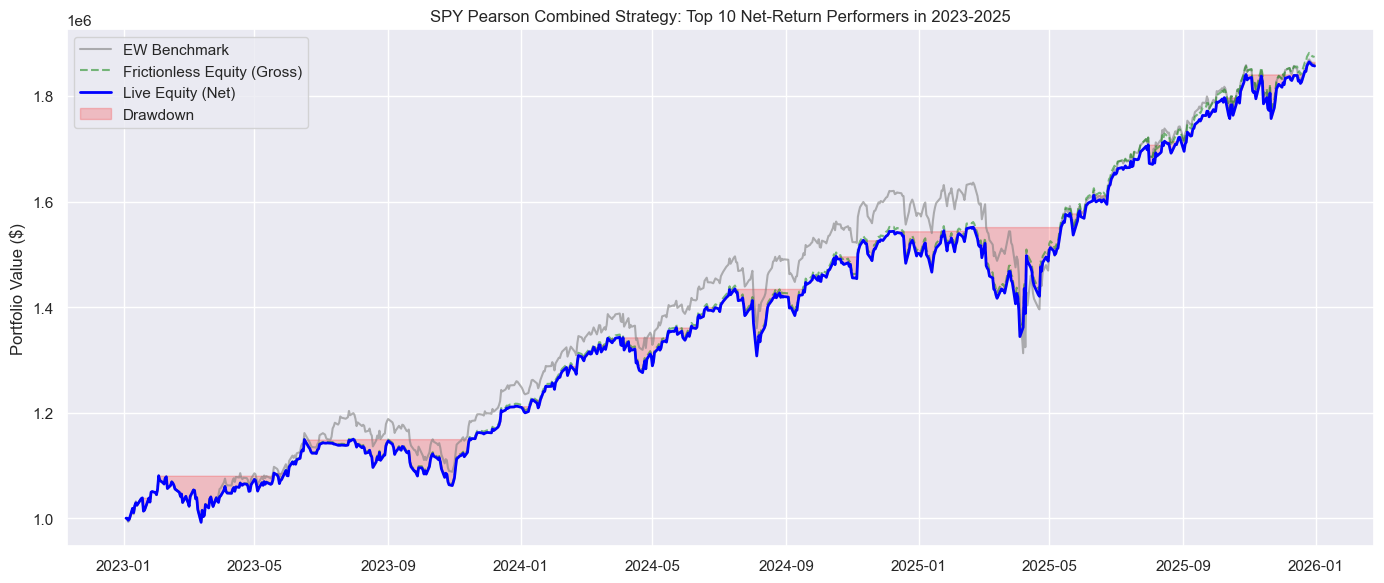

,grid_index,run_id,n_features,signal_threshold,position_size
0,65,SPY_features-9_sig-0p001,9,0.001,0.1
1,106,SPY_features-14_sig-0p002,14,0.002,0.1
2,48,SPY_features-7_sig-0,7,0.000,0.1
3,81,SPY_features-11_sig-0p001,11,0.001,0.1
4,98,SPY_features-13_sig-0p002,13,0.002,0.1
5,2,SPY_features-1_sig-0p002,1,0.002,0.1
6,32,SPY_features-5_sig-0,5,0.000,0.1
7,10,SPY_features-2_sig-0p002,2,0.002,0.1
8,16,SPY_features-3_sig-0,3,0.000,0.1
9,3,SPY_features-1_sig-0p003,1,0.003,0.1


,SPY_features-9_sig-0p001,SPY_features-14_sig-0p002,SPY_features-7_sig-0,SPY_features-11_sig-0p001,SPY_features-13_sig-0p002,SPY_features-1_sig-0p002,SPY_features-5_sig-0,SPY_features-2_sig-0p002,SPY_features-3_sig-0,SPY_features-1_sig-0p003
Timestamp,,,,,,,,,,
2023-01-03,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2023-01-04,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2023-01-05,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2023-01-06,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2023-01-09,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1


,SPY
Timestamp,
2023-01-03,1.0
2023-01-04,1.0
2023-01-05,1.0
2023-01-06,1.0
2023-01-09,1.0


,gross_returns,gross_equity,total_costs_usd,cumulative_costs,net_equity,net_returns,cum_benchmark
Timestamp,,,,,,,
2025-12-24,0.005893,1.874360e+06,3.168491e-12,16978.238483,1.857382e+06,0.005947,1.861933
2025-12-26,0.003910,1.881689e+06,5.009363e+01,17028.332112,1.864661e+06,0.003919,1.869214
2025-12-29,-0.003591,1.874932e+06,3.954958e+01,17067.881692,1.857865e+06,-0.003645,1.860823
2025-12-30,-0.000131,1.874687e+06,0.000000e+00,17067.881692,1.857619e+06,-0.000132,1.860580
2025-12-31,-0.000451,1.873842e+06,0.000000e+00,17067.881692,1.856774e+06,-0.000455,1.859741


In [19]:
from src.vector_backtester_Mateo import PortfolioVectorEngine

top_10_return_rows_2023_2025 = (
    metrics_df_2023_2025
    .sort_values("net_return_pct", ascending=False)
    .head(10)
)

combined_specs_2023_2025_top10 = []
for grid_index, row in top_10_return_rows_2023_2025.iterrows():
    combined_specs_2023_2025_top10.append({
        "grid_index": grid_index,
        "run_id": row["run_id"],
        "n_features": int(row["n_features"]),
        "signal_threshold": float(row["signal_threshold"]),
        "position_size": 0.1,
    })

combined_artifacts_2023_2025_top10 = {}
combined_weights_parts_2023_2025_top10 = []

for spec in combined_specs_2023_2025_top10:
    run_id = spec["run_id"]

    artifacts = run_single_case_features_capture(
        symbol=SYMBOL,
        asset_class=ASSET_CLASS,
        start_date=COMMON_PARAMS_2023_2025["start_date"],
        end_date=COMMON_PARAMS_2023_2025["end_date"],
        signal_threshold=spec["signal_threshold"],
        n_features=spec["n_features"],
        training_years=COMMON_PARAMS_2023_2025["training_years"],
        sharpe_filter_enabled=COMMON_PARAMS_2023_2025["sharpe_filter_enabled"],
        feature_diagnostics_enabled=COMMON_PARAMS_2023_2025["feature_diagnostics_enabled"],
        feature_diagnostics_top_n=COMMON_PARAMS_2023_2025["feature_diagnostics_top_n"],
        position_size=spec["position_size"],
        initial_capital=INITIAL_CAPITAL,
        max_iter=COMMON_PARAMS_2023_2025["max_iter"],
        execution_delay=EXECUTION_DELAY,
        verbose=COMMON_PARAMS_2023_2025["verbose"],
        show_progress=SHOW_PROGRESS,
        show_tearsheet=False,
    )

    combined_artifacts_2023_2025_top10[run_id] = artifacts
    combined_weights_parts_2023_2025_top10.append(
        artifacts["weights"].rename(columns={SYMBOL: run_id})
    )

combined_component_weights_2023_2025_top10 = pd.concat(
    combined_weights_parts_2023_2025_top10,
    axis=1,
).fillna(0)

combined_weights_2023_2025_top10 = pd.DataFrame(
    {SYMBOL: combined_component_weights_2023_2025_top10.sum(axis=1)},
    index=combined_component_weights_2023_2025_top10.index,
)

combined_prices_2023_2025_top10 = (
    next(iter(combined_artifacts_2023_2025_top10.values()))["prices"]
    .loc[combined_weights_2023_2025_top10.index]
)

combined_engine_2023_2025_top10 = PortfolioVectorEngine(
    prices=combined_prices_2023_2025_top10,
    signals=combined_weights_2023_2025_top10,
    asset_class=ASSET_CLASS,
    initial_capital=INITIAL_CAPITAL,
    execution_delay=EXECUTION_DELAY,
)

combined_stats_2023_2025_top10 = combined_engine_2023_2025_top10.run()
combined_engine_2023_2025_top10.tearsheet(
    "SPY Pearson Combined Strategy: Top 10 Net-Return Performers in 2023-2025"
)

combined_strategy_2023_2025_top10 = {
    "symbol": SYMBOL,
    "specs": combined_specs_2023_2025_top10,
    "component_artifacts": combined_artifacts_2023_2025_top10,
    "component_weights": combined_component_weights_2023_2025_top10,
    "weights": combined_weights_2023_2025_top10,
    "prices": combined_prices_2023_2025_top10,
    "engine": combined_engine_2023_2025_top10,
    "stats": combined_stats_2023_2025_top10,
}

display(pd.DataFrame(combined_specs_2023_2025_top10))
display(combined_component_weights_2023_2025_top10.head())
display(combined_weights_2023_2025_top10.head())
display(combined_stats_2023_2025_top10.tail())

Now test how this combined strategy would work on `2026 – YTD`


📊 --- QUICK PORTFOLIO RESULTS: SPY Pearson Combined Strategy: Top 10 Net-Return Performers in 2023-2025 ---
   Frictionless Return:     3.19%
   Net Strategy Return:     2.98%  (EW Benchmark: 8.68%)
   Max Drawdown:            -6.97%
   Win Rate (Gross Bars):   51.6%   (EW Benchmark: 54.9%)
   Loss Rate (Gross Bars):  45.1%   (EW Benchmark: 45.1%)
   Zero Rate (Gross Bars):  3.3%    (EW Benchmark: 0.0%)
   Sharpe Ratio (Net):      0.58    (EW Benchmark: 1.34)
   Sortino/√2 (Net):        0.58    (EW Benchmark: 1.45)
   Total Fees Paid:         $2,127.46
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/SPY_Pearson_Combined_Strategy:_Top_10_Net-Return_Performers_in_2023-2025_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


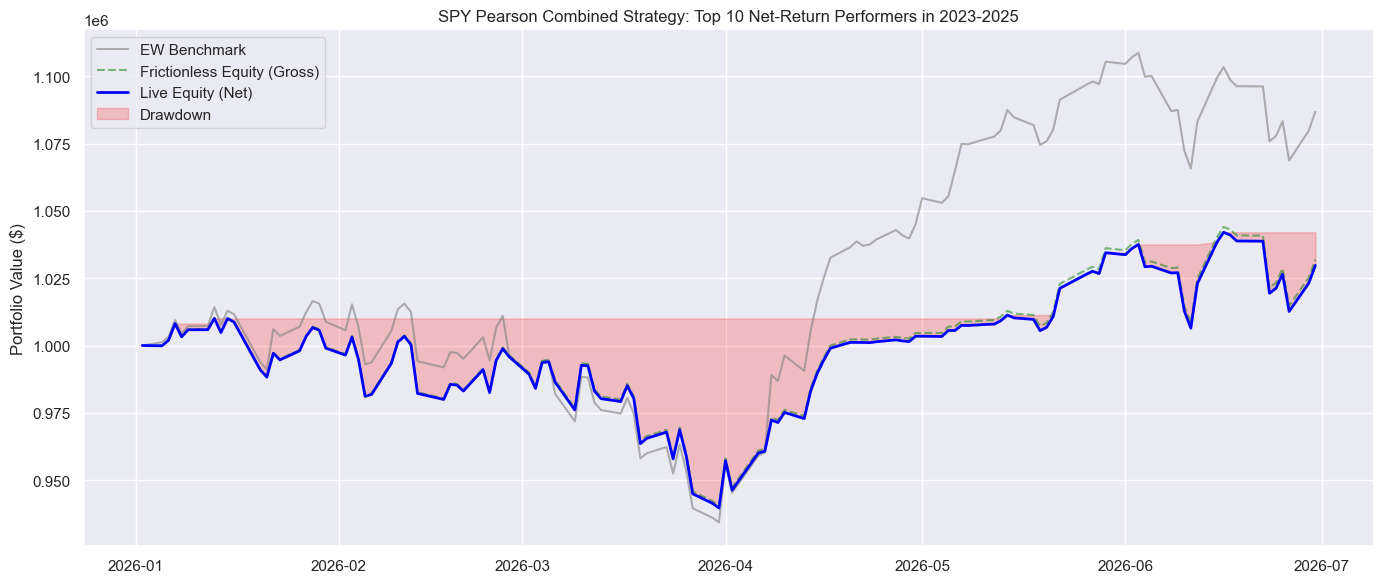

,grid_index,run_id,n_features,signal_threshold,position_size
0,65,SPY_features-9_sig-0p001,9,0.001,0.1
1,106,SPY_features-14_sig-0p002,14,0.002,0.1
2,48,SPY_features-7_sig-0,7,0.000,0.1
3,81,SPY_features-11_sig-0p001,11,0.001,0.1
4,98,SPY_features-13_sig-0p002,13,0.002,0.1
5,2,SPY_features-1_sig-0p002,1,0.002,0.1
6,32,SPY_features-5_sig-0,5,0.000,0.1
7,10,SPY_features-2_sig-0p002,2,0.002,0.1
8,16,SPY_features-3_sig-0,3,0.000,0.1
9,3,SPY_features-1_sig-0p003,1,0.003,0.1


,SPY_features-9_sig-0p001,SPY_features-14_sig-0p002,SPY_features-7_sig-0,SPY_features-11_sig-0p001,SPY_features-13_sig-0p002,SPY_features-1_sig-0p002,SPY_features-5_sig-0,SPY_features-2_sig-0p002,SPY_features-3_sig-0,SPY_features-1_sig-0p003
Timestamp,,,,,,,,,,
2026-01-02,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2026-01-05,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2026-01-06,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2026-01-07,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2026-01-08,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1


,SPY
Timestamp,
2026-01-02,1.0
2026-01-05,1.0
2026-01-06,1.0
2026-01-07,1.0
2026-01-08,1.0


,gross_returns,gross_equity,total_costs_usd,cumulative_costs,net_equity,net_returns,cum_benchmark
Timestamp,,,,,,,
2026-06-24,0.001853,1.023365e+06,1.688299e-12,2072.668442,1.021292e+06,0.001857,1.077827
2026-06-25,0.005087,1.028571e+06,1.701596e-12,2072.668442,1.026498e+06,0.005098,1.083310
2026-06-26,-0.013479,1.014706e+06,0.000000e+00,2072.668442,1.012634e+06,-0.013506,1.068708
2026-06-29,0.010399,1.025258e+06,0.000000e+00,2072.668442,1.023185e+06,0.010420,1.079821
2026-06-30,0.006463,1.031884e+06,5.479114e+01,2127.459587,1.029756e+06,0.006422,1.086800


In [20]:
from src.vector_backtester_Mateo import PortfolioVectorEngine

top_10_return_rows_2023_2025 = (
    metrics_df_2023_2025
    .sort_values("net_return_pct", ascending=False)
    .head(10)
)

combined_specs_2023_2025_top10 = []
for grid_index, row in top_10_return_rows_2023_2025.iterrows():
    combined_specs_2023_2025_top10.append({
        "grid_index": grid_index,
        "run_id": row["run_id"],
        "n_features": int(row["n_features"]),
        "signal_threshold": float(row["signal_threshold"]),
        "position_size": 0.1,
    })

combined_artifacts_2023_2025_top10 = {}
combined_weights_parts_2023_2025_top10 = []

for spec in combined_specs_2023_2025_top10:
    run_id = spec["run_id"]

    artifacts = run_single_case_features_capture(
        symbol=SYMBOL,
        asset_class=ASSET_CLASS,
        start_date="2026-01-01",
        end_date="2026-07-01",
        signal_threshold=spec["signal_threshold"],
        n_features=spec["n_features"],
        training_years=COMMON_PARAMS_2023_2025["training_years"],
        sharpe_filter_enabled=COMMON_PARAMS_2023_2025["sharpe_filter_enabled"],
        feature_diagnostics_enabled=COMMON_PARAMS_2023_2025["feature_diagnostics_enabled"],
        feature_diagnostics_top_n=COMMON_PARAMS_2023_2025["feature_diagnostics_top_n"],
        position_size=spec["position_size"],
        initial_capital=INITIAL_CAPITAL,
        max_iter=COMMON_PARAMS_2023_2025["max_iter"],
        execution_delay=EXECUTION_DELAY,
        verbose=COMMON_PARAMS_2023_2025["verbose"],
        show_progress=SHOW_PROGRESS,
        show_tearsheet=False,
    )

    combined_artifacts_2023_2025_top10[run_id] = artifacts
    combined_weights_parts_2023_2025_top10.append(
        artifacts["weights"].rename(columns={SYMBOL: run_id})
    )

combined_component_weights_2023_2025_top10 = pd.concat(
    combined_weights_parts_2023_2025_top10,
    axis=1,
).fillna(0)

combined_weights_2023_2025_top10 = pd.DataFrame(
    {SYMBOL: combined_component_weights_2023_2025_top10.sum(axis=1)},
    index=combined_component_weights_2023_2025_top10.index,
)

combined_prices_2023_2025_top10 = (
    next(iter(combined_artifacts_2023_2025_top10.values()))["prices"]
    .loc[combined_weights_2023_2025_top10.index]
)

combined_engine_2023_2025_top10 = PortfolioVectorEngine(
    prices=combined_prices_2023_2025_top10,
    signals=combined_weights_2023_2025_top10,
    asset_class=ASSET_CLASS,
    initial_capital=INITIAL_CAPITAL,
    execution_delay=EXECUTION_DELAY,
)

combined_stats_2023_2025_top10 = combined_engine_2023_2025_top10.run()
combined_engine_2023_2025_top10.tearsheet(
    "SPY Pearson Combined Strategy: Top 10 Net-Return Performers in 2023-2025"
)

combined_strategy_2023_2025_top10 = {
    "symbol": SYMBOL,
    "specs": combined_specs_2023_2025_top10,
    "component_artifacts": combined_artifacts_2023_2025_top10,
    "component_weights": combined_component_weights_2023_2025_top10,
    "weights": combined_weights_2023_2025_top10,
    "prices": combined_prices_2023_2025_top10,
    "engine": combined_engine_2023_2025_top10,
    "stats": combined_stats_2023_2025_top10,
}

display(pd.DataFrame(combined_specs_2023_2025_top10))
display(combined_component_weights_2023_2025_top10.head())
display(combined_weights_2023_2025_top10.head())
display(combined_stats_2023_2025_top10.tail())

## Single Candidate Rerun With Tearsheet



Use this section after the grid to rerun any candidate with the full tearsheet output. The grid suppresses tearsheets so the parallel run stays readable.

Rerunning SPY_features-18_sig-0p0075 with tearsheet output
🧠 Predicting 2025-12-31 |  250/250 |  last: 0.58s |  elapsed: 1m 59.5s
✅ Prediction complete. Took 2m 0.5s


📊 --- QUICK PORTFOLIO RESULTS: SPY ML Walk Forward ---
   Frictionless Return:     27.27%
   Net Strategy Return:     26.79%  (EW Benchmark: 17.95%)
   Max Drawdown:            -2.37%
   Win Rate (Gross Bars):   6.4%   (EW Benchmark: 56.6%)
   Loss Rate (Gross Bars):  4.0%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  89.6%    (EW Benchmark: 0.4%)
   Sharpe Ratio (Net):      2.06    (EW Benchmark: 0.92)
   Sortino/√2 (Net):        5.78    (EW Benchmark: 0.97)
   Total Fees Paid:         $4,754.97
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/SPY_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


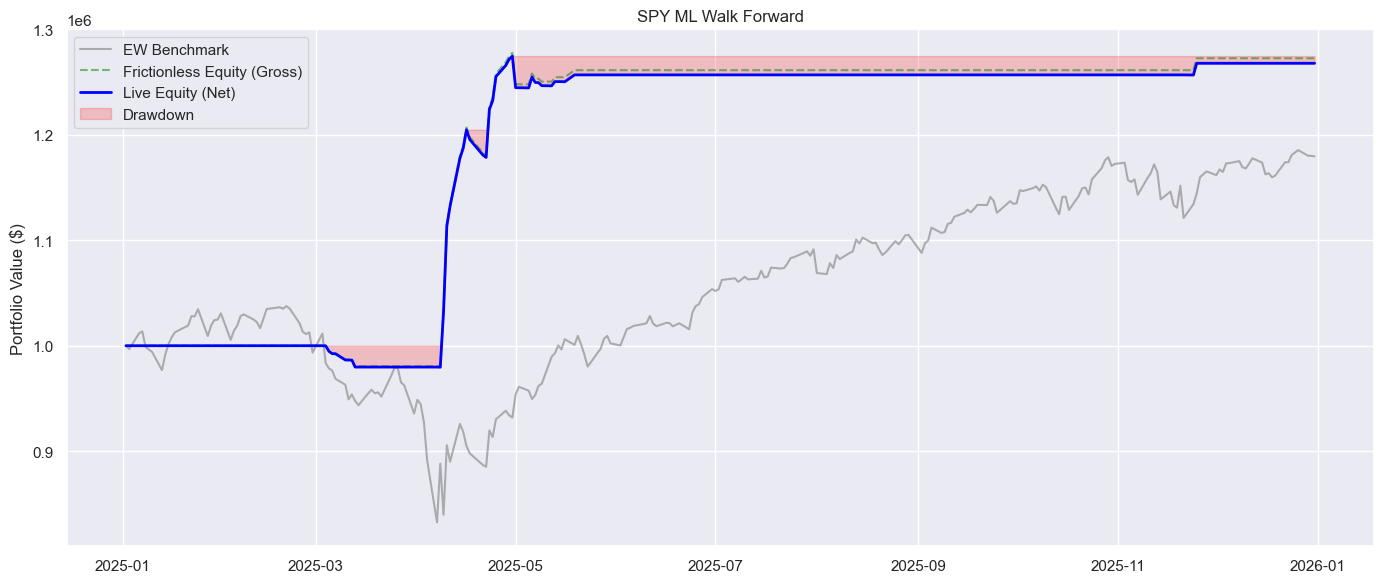

run_id,SPY_features-18_sig-0p0075
grid_index,142
symbol,SPY
n_features,18
signal_threshold,0.0075
training_years,10
start_date,2025-01-01
end_date,2026-01-01
gross_return_pct,27.265778
net_return_pct,26.79028
benchmark_return_pct,17.954018


In [17]:
target_run_id = metrics_df.sort_values("net_sharpe", ascending=False).iloc[0]["run_id"]
target = metrics_df.set_index("run_id").loc[target_run_id]
target_grid_index = int(metrics_df[metrics_df["run_id"] == target_run_id].index[0])

print(f"Rerunning {target_run_id} with tearsheet output")

single_artifacts = run_single_case_features_capture(
    symbol=SYMBOL,
    asset_class=ASSET_CLASS,
    start_date=COMMON_PARAMS_2025["start_date"],
    end_date=COMMON_PARAMS_2025["end_date"],
    signal_threshold=float(target["signal_threshold"]),
    n_features=int(target["n_features"]),
    training_years=COMMON_PARAMS_2025["training_years"],
    sharpe_filter_enabled=COMMON_PARAMS_2025["sharpe_filter_enabled"],
    feature_diagnostics_enabled=COMMON_PARAMS_2025["feature_diagnostics_enabled"],
    feature_diagnostics_top_n=COMMON_PARAMS_2025["feature_diagnostics_top_n"],
    position_size=COMMON_PARAMS_2025["position_size"],
    initial_capital=INITIAL_CAPITAL,
    max_iter=COMMON_PARAMS_2025["max_iter"],
    execution_delay=EXECUTION_DELAY,
    verbose=COMMON_PARAMS_2025["verbose"],
    show_progress=True,
    show_tearsheet=True,
)

single_metrics = summarize_performance(
    target_run_id,
    target_grid_index,
    single_artifacts["params"],
    single_artifacts["stats"],
    single_artifacts["weights"],
    single_artifacts["strategy"],
)

display(pd.DataFrame([single_metrics]).set_index("run_id").T)

Rerunning SPY_features-18_sig-0p0075 with tearsheet output
🧠 Predicting 2025-12-31 |  1508/1508 |  last: 0.79s |  elapsed: 13m 22.8s
✅ Prediction complete. Took 13m 24.1s


📊 --- QUICK PORTFOLIO RESULTS: SPY ML Walk Forward ---
   Frictionless Return:     129.92%
   Net Strategy Return:     125.73%  (EW Benchmark: 131.77%)
   Max Drawdown:            -13.15%
   Win Rate (Gross Bars):   9.8%   (EW Benchmark: 55.7%)
   Loss Rate (Gross Bars):  6.8%   (EW Benchmark: 44.2%)
   Zero Rate (Gross Bars):  83.4%    (EW Benchmark: 0.1%)
   Sharpe Ratio (Net):      1.08    (EW Benchmark: 0.81)
   Sortino/√2 (Net):        1.28    (EW Benchmark: 0.79)
   Total Fees Paid:         $41,907.08
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/SPY_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


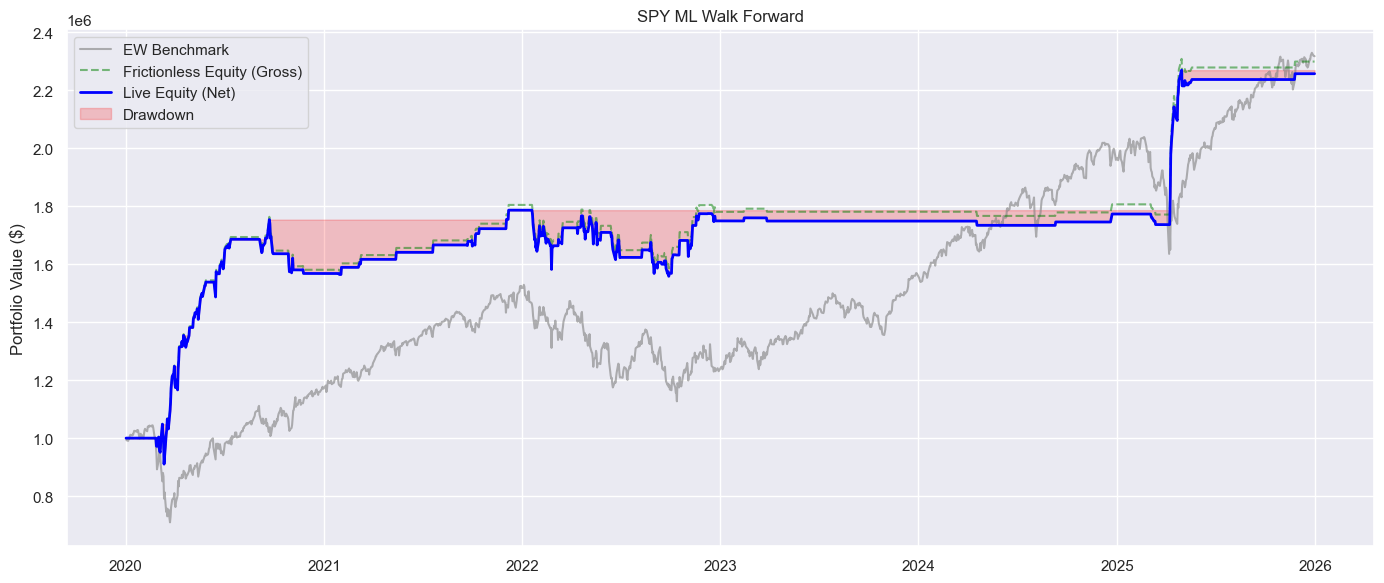

run_id,SPY_features-18_sig-0p0075
grid_index,142
symbol,SPY
n_features,18
signal_threshold,0.0075
training_years,10
start_date,2020-01-01
end_date,2026-01-01
gross_return_pct,129.923819
net_return_pct,125.733111
benchmark_return_pct,131.765857


In [18]:
target_run_id = metrics_df.sort_values("net_sharpe", ascending=False).iloc[0]["run_id"]
target = metrics_df.set_index("run_id").loc[target_run_id]
target_grid_index = int(metrics_df[metrics_df["run_id"] == target_run_id].index[0])

print(f"Rerunning {target_run_id} with tearsheet output")

single_artifacts = run_single_case_features_capture(
    symbol=SYMBOL,
    asset_class=ASSET_CLASS,
    # start_date=COMMON_PARAMS_2025["start_date"],
    start_date="2020-01-01",
    # end_date=COMMON_PARAMS_2025["end_date"],
    end_date="2026-01-01",
    signal_threshold=float(target["signal_threshold"]),
    n_features=int(target["n_features"]),
    training_years=COMMON_PARAMS_2025["training_years"],
    sharpe_filter_enabled=COMMON_PARAMS_2025["sharpe_filter_enabled"],
    feature_diagnostics_enabled=COMMON_PARAMS_2025["feature_diagnostics_enabled"],
    feature_diagnostics_top_n=COMMON_PARAMS_2025["feature_diagnostics_top_n"],
    position_size=COMMON_PARAMS_2025["position_size"],
    initial_capital=INITIAL_CAPITAL,
    max_iter=COMMON_PARAMS_2025["max_iter"],
    execution_delay=EXECUTION_DELAY,
    verbose=COMMON_PARAMS_2025["verbose"],
    show_progress=True,
    show_tearsheet=True,
)

single_metrics = summarize_performance(
    target_run_id,
    target_grid_index,
    single_artifacts["params"],
    single_artifacts["stats"],
    single_artifacts["weights"],
    single_artifacts["strategy"],
)

display(pd.DataFrame([single_metrics]).set_index("run_id").T)